In [56]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

data_folder="/Users/giovanni.messuti/Desktop/BCI_Project/Data/"

freq_personalized = {"subject_0":[9,14.5],
                     "subject_1":[8,12],
                     "subject_2":[8,13.5],
                     "subject_3":[4,9.5],
                     "subject_4":[18,23.5],
                     "subject_5":[4,9.5],
                     "subject_6":[4,9.5],
                     "subject_7":[4,9.5],
                     "subject_8":[4,12],
                     "subject_9":[9.5,15.5],
                     "subject_10":[9,14.5],
                     "subject_11":[4,10.5],
                     "subject_12":[8,13.5],
                     "subject_13":[4,10.],
                     "subject_14":[12,18],
                     "subject_15":[4,8],
                     "subject_16":[4,13],
                     "subject_17":[4,12],
                     "subject_18":[4,9.5],
                     "subject_19":[4,12.5],
}

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, saveresults_pickle, select_rows
from BCI_Library import sort_rank, compute_welch_select_regions, extract_features_from_spectra_more_bands,compute_welch
from BCI_Library import plot_hist2d_selected_regions_folds

"""# new_row = {
#     "ROIs": [selected_regions_EEG],
#     "NROIs":[25]
#     "DataType": ["EEG"],
#     "freqs_band": [((4,8),(8,12),(12,30))],  
#     "subject": [subject_index],
#     "Classifier": ["LDA"],
#     "Performance": [training[0]],
#     "Features": ["PowerSpectra - MeanMax band"],
#     "Comments": ["-"],
#     "Date": [today],
#     "Personalized_Freq_Range" = False,
# }"""


'# new_row = {\n#     "ROIs": [selected_regions_EEG],\n#     "NROIs":[25]\n#     "DataType": ["EEG"],\n#     "freqs_band": [((4,8),(8,12),(12,30))],  \n#     "subject": [subject_index],\n#     "Classifier": ["LDA"],\n#     "Performance": [training[0]],\n#     "Features": ["PowerSpectra - MeanMax band"],\n#     "Comments": ["-"],\n#     "Date": [today],\n#     "Personalized_Freq_Range" = False,\n# }'

# Power spectra features - investigate EEG

In [126]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

subject_index =11

data_2_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_2_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250

In [127]:
# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)

fmin=5
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

wpsdMI, frequiMI = psd_array_welch(data_2_MI[:,:,stime:-etime], **kargs )
wpsdRest, frequiRest = psd_array_welch(data_2_Rest[:,:,stime:-etime], **kargs )
wpsdRest.shape


Effective window size : 1.200 (s)
Effective window size : 1.200 (s)


(96, 68, 31)

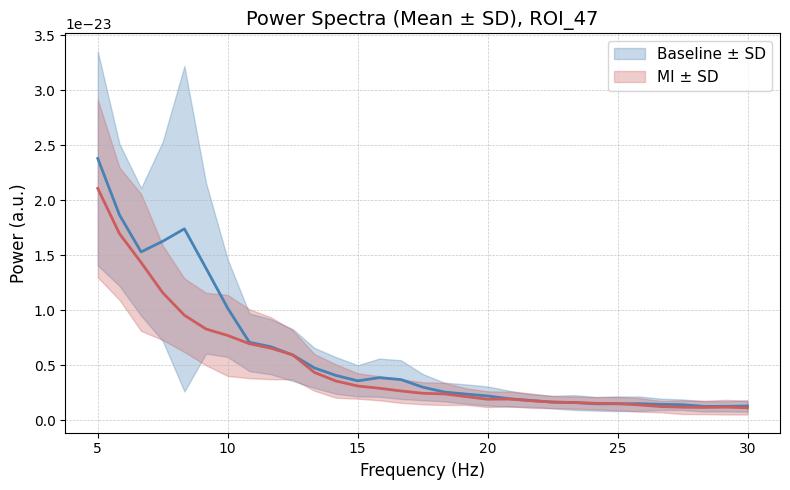

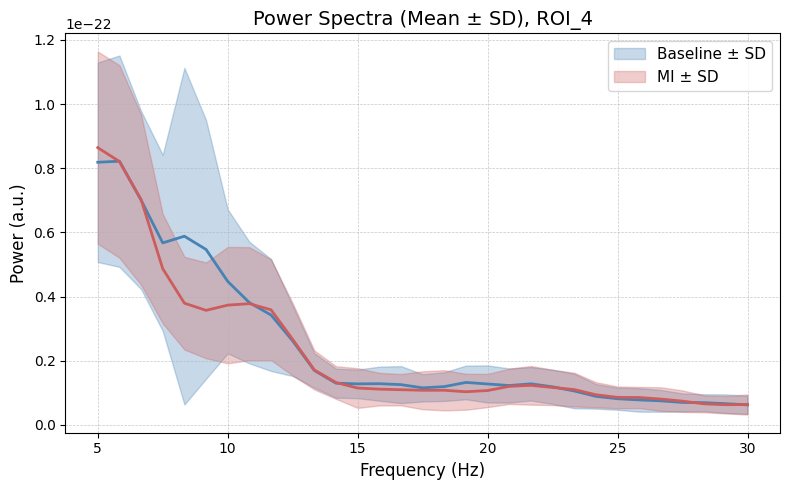

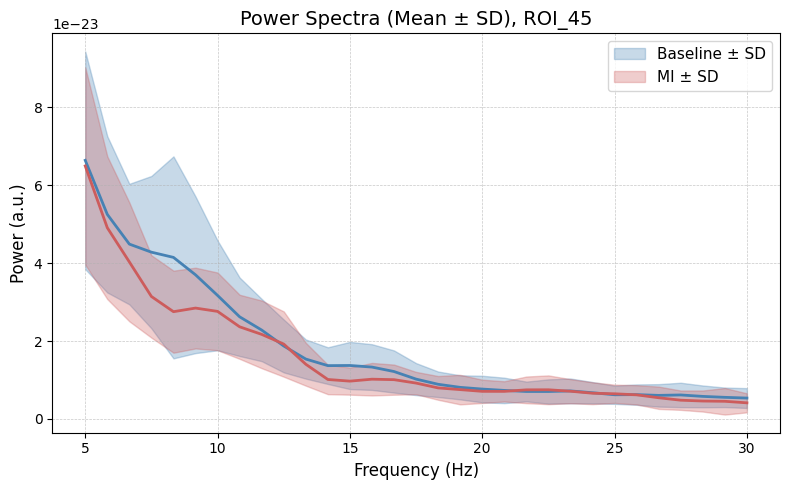

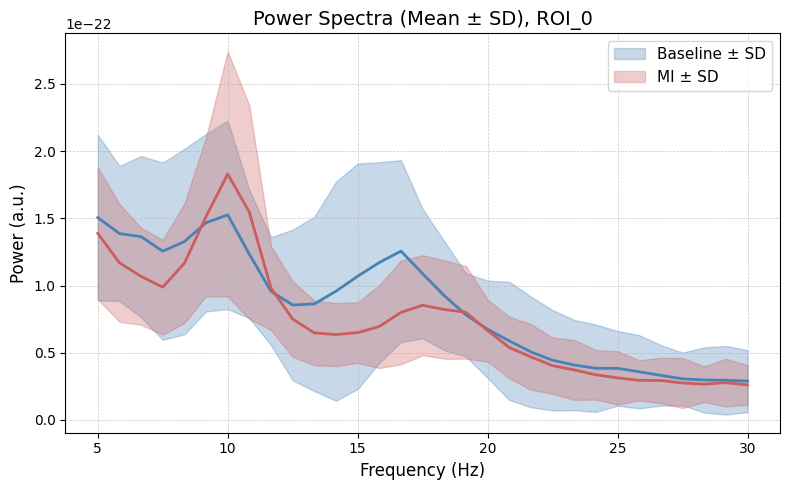

[4, 5, 32, 33, 44, 45, 48, 49]

In [129]:
# some plot


def plot_spectra(wpsdMI_1ROI,wpsdRest_1ROI,ROI=None):

    wpsd_MI_std = wpsdMI_1ROI.std(axis=0)
    wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)

    wpsd_Rest_std = wpsdRest_1ROI.std(axis=0)
    wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)

    plt.figure(figsize=(8,5))

    plt.fill_between(
        frequiRest, 
        wpsd_Rest_mean - wpsd_Rest_std, 
        wpsd_Rest_mean + wpsd_Rest_std,
        color="steelblue", alpha=0.3, label="Baseline ± SD"
    )
    plt.plot(frequiRest, wpsd_Rest_mean, color="steelblue", linewidth=2)

    plt.fill_between(
        frequiMI, 
        wpsd_MI_mean - wpsd_MI_std, 
        wpsd_MI_mean + wpsd_MI_std,
        color="indianred", alpha=0.3, label="MI ± SD"
    )
    plt.plot(frequiMI, wpsd_MI_mean, color="indianred", linewidth=2)


    plt.title(f"Power Spectra (Mean ± SD), ROI_{ROI}", fontsize=14)
    plt.xlabel("Frequency (Hz)", fontsize=12)
    plt.ylabel("Power (a.u.)", fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ylims = plt.ylim()
    #plt.vlines((4,8,12,30),0, ylims[1],linestyles="--",color="navy",alpha=.8)
    plt.ylim(ylims)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


for ROI in [47,4,45,0]:
    wpsdMI_1ROI =wpsdMI[:,ROI,:]
    wpsdRest_1ROI =wpsdRest[:,ROI,:] 
    #plot_spectra(wpsdMI_1ROI[index_per_fold[0][0:72]],wpsdRest_1ROI[index_per_fold[0][72:]-90],ROI)
    plot_spectra(wpsdMI_1ROI, wpsdRest_1ROI, ROI)

[4, 5, 32, 33, 44, 45, 48, 49]

### other

In [32]:
# selecting the ROIs where the difference between MI and Rest is max 

i_freq_max_rest=[] # indici delle frequenze di dove é il massimo
i_freq_max_diff=[] # .... where i find the max of diff
max_rest=[]
max_diff_perc=[] # max of the difference reported in percentage, not the maximum of the percentage difference

for roi in range(68):
    wpsdMI_1ROI =wpsdMI[:,roi,:]
    wpsdRest_1ROI =wpsdRest[:,roi,:]
    wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)
    wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)
    
    max_rest.append(np.max(wpsd_Rest_mean))
    # non lax rest, ma rest in quel bin
    max_diff_perc.append(np.max(wpsd_Rest_mean-wpsd_MI_mean)/max_rest[-1])

    i_freq_max_rest.append(np.argmax(wpsd_Rest_mean))
    i_freq_max_diff.append(np.argmax(wpsd_Rest_mean-wpsd_MI_mean))

i_freq_max_diff=np.array(i_freq_max_diff)
np.argsort(max_diff_perc) # from smaller to bigger

array([56, 57, 10,  5, 18, 29, 52,  3, 53, 54, 48, 55, 38, 36, 40,  2, 39,
       28, 64,  4, 60, 24, 25, 33, 11, 44, 49, 37, 63, 41, 65, 19, 31, 45,
       35, 46,  8, 16, 13, 14, 12,  9, 66,  0, 15, 22, 58, 47, 34, 23, 30,
        6, 27, 62, 20, 21, 50,  7, 32, 26,  1, 17, 51, 42, 59, 43, 61, 67])

In [33]:
# I choose the nregions where I have the greatest difference between MI and Rest 
# (but being careful to include the Interesting_regions)
nregions = 34 
selected_regions = [i for i in Interesting_regions]
for i in range(68):
    if np.argsort(max_diff_perc)[-i-1] not in selected_regions:
        selected_regions.append(int(np.argsort(max_diff_perc)[-i-1]))
    if len(selected_regions) >= nregions:
        break
    

array([10.        , 10.83333333, 11.66666667])

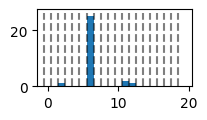

In [34]:
plt.figure(figsize=(2,1)) 
plt.hist(i_freq_max_diff[selected_regions],bins=np.array([i for i in range(20)])+0.5)
plt.vlines([i-0.5 for i in range(20)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)
frequiMI[[6,7,8]]
# the maximum difference for subject 2 is found at freqs with indexes 6,7,8

In [35]:
frequiMI

array([ 5.        ,  5.83333333,  6.66666667,  7.5       ,  8.33333333,
        9.16666667, 10.        , 10.83333333, 11.66666667, 12.5       ,
       13.33333333, 14.16666667, 15.        , 15.83333333, 16.66666667,
       17.5       , 18.33333333, 19.16666667, 20.        , 20.83333333,
       21.66666667, 22.5       , 23.33333333, 24.16666667, 25.        ,
       25.83333333, 26.66666667, 27.5       , 28.33333333, 29.16666667,
       30.        ])

In [36]:
min_freq_frature = 8
max_freq_feature = 14
start_freq_idx = np.where(frequiMI>=min_freq_frature)[0][0]
end_freq_idx = np.where(frequiMI<=max_freq_feature)[0][-1]

In [37]:
wpsdRest_ROIs_freqs = wpsdRest[:,selected_regions,start_freq_idx:end_freq_idx]
wpsdMI_ROIs_freqs = wpsdMI[:,selected_regions,start_freq_idx:end_freq_idx]
wpsdRest_ROIs_freqs.shape

(94, 34, 6)

In [40]:
# as features i chose the max and the maen of selected_ROIs in freqs 8.3 to 13.3
features_MI = np.concatenate((wpsdMI_ROIs_freqs.mean(axis=-1,keepdims=True),
                              wpsdMI_ROIs_freqs.max(axis=-1,keepdims=True)),
                              axis=-1)
print(features_MI.shape)
features_MI = features_MI.reshape(94,-1)

features_Rest = np.concatenate((wpsdRest_ROIs_freqs.mean(axis=-1,keepdims=True),
                              wpsdRest_ROIs_freqs.max(axis=-1,keepdims=True)),
                              axis=-1)
features_Rest = features_Rest.reshape(94,-1)

features_MI.reshape(94,-1).shape
# for each trial i have mean and max of each ROI: 2 features for each of the 34 ROI:
# for each trial i have 68 features (both for Rest and MI tasks)

(94, 34, 2)


(94, 68)

In [41]:
features = np.concatenate((features_Rest,features_MI),axis=0)
labels = np.array([0 for i in range (94)] + [1 for i in range (94)]) # 0 for Rest, 1 for MI
features.shape


(188, 68)

In [42]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

kf = KFold(n_splits=5, shuffle=True, random_state=264)

fold_accuracies = []
fold_confusions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features)):
    print(f"\n----- Fold {fold_idx+1} -----")

    X_train, X_val = features[train_idx], features[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    # StandardScaler:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    # LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)

    # Predict on validation
    y_pred = lda.predict(X_val_scaled)

    # Accuracy
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies.append(acc)

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_confusions.append(cm)

    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
    print(cm)

# Summary
print("==================================")
print("Mean accuracy:", np.mean(fold_accuracies))
print("Std accuracy:", np.std(fold_accuracies))




----- Fold 1 -----
Fold 1 accuracy: 0.6579, Confusion matrix:
[[14  6]
 [ 7 11]]

----- Fold 2 -----
Fold 2 accuracy: 0.4737, Confusion matrix:
[[ 6  7]
 [13 12]]

----- Fold 3 -----
Fold 3 accuracy: 0.6053, Confusion matrix:
[[13  9]
 [ 6 10]]

----- Fold 4 -----
Fold 4 accuracy: 0.4865, Confusion matrix:
[[10  7]
 [12  8]]

----- Fold 5 -----
Fold 5 accuracy: 0.7027, Confusion matrix:
[[12 10]
 [ 1 14]]
Mean accuracy: 0.5852062588904694
Std accuracy: 0.09129520148172625


# Power spectra features - investigate MEG

In [8]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

subject_index=4

data_2_MI = read_subject(data_folder, "MEG", "MI",subject_index)
data_2_Rest = read_subject(data_folder, "MEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250

In [9]:
# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)

fmin=3
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

wpsdMI_MEG, frequiMI_MEG = psd_array_welch(data_2_MI_MEG[:,:,stime:-etime], **kargs )
wpsdRest_MEG, frequiRest_MEG = psd_array_welch(data_2_Rest_MEG[:,:,stime:-etime], **kargs )
wpsdRest_MEG.shape


NameError: name 'data_2_MI_MEG' is not defined

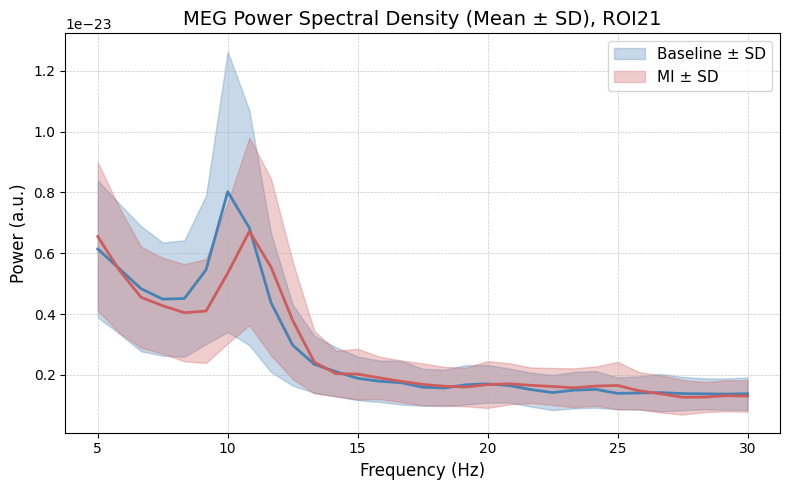

In [47]:
# some plot
ROI = 21
wpsdMI_1ROI_MEG =wpsdMI_MEG[:,ROI,:]
wpsdRest_1ROI_MEG =wpsdRest_MEG[:,ROI,:]

wpsd_MI_std_MEG = wpsdMI_1ROI_MEG.std(axis=0)
wpsd_MI_mean_MEG = wpsdMI_1ROI_MEG.mean(axis=0)

wpsd_Rest_std_MEG = wpsdRest_1ROI_MEG.std(axis=0)
wpsd_Rest_mean_MEG = wpsdRest_1ROI_MEG.mean(axis=0)

plt.figure(figsize=(8, 5))

# --- Baseline condition ---
plt.fill_between(
    frequiRest_MEG, 
    wpsd_Rest_mean_MEG - wpsd_Rest_std_MEG, 
    wpsd_Rest_mean_MEG + wpsd_Rest_std_MEG,
    color="steelblue", alpha=0.3, label="Baseline ± SD"
)
plt.plot(frequiRest_MEG, wpsd_Rest_mean_MEG, color="steelblue", linewidth=2)

# --- MI condition ---
plt.fill_between(
    frequiMI_MEG, 
    wpsd_MI_mean_MEG- wpsd_MI_std_MEG, 
    wpsd_MI_mean_MEG + wpsd_MI_std_MEG,
    color="indianred", alpha=0.3, label="MI ± SD"
)
plt.plot(frequiMI_MEG, wpsd_MI_mean_MEG, color="indianred", linewidth=2)


plt.title(f"MEG Power Spectral Density (Mean ± SD), ROI{ROI}", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Power (a.u.)", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [48]:
# selecting the ROIs where the difference between MI and Rest is max 

i_freq_max_rest_MEG=[] # indici delle frequenze di dove é il massimo
i_freq_max_diff_MEG=[] # .... where i find the max of diff
max_rest_MEG=[]
max_diff_perc_MEG=[] # max of the difference reported in percentage, not the maximum of the percentage difference

for roi in range(68):
    wpsdMI_1ROI_MEG =wpsdMI_MEG[:,roi,:]
    wpsdRest_1ROI_MEG =wpsdRest_MEG[:,roi,:]
    wpsd_MI_mean_MEG = wpsdMI_1ROI_MEG.mean(axis=0)
    wpsd_Rest_mean_MEG = wpsdRest_1ROI_MEG.mean(axis=0)
    
    max_rest_MEG.append(np.max(wpsd_Rest_mean_MEG))
    max_diff_perc_MEG.append(np.max(wpsd_Rest_mean_MEG-wpsd_MI_mean_MEG)/max_rest_MEG[-1])

    i_freq_max_rest_MEG.append(np.argmax(wpsd_Rest_mean_MEG))
    i_freq_max_diff_MEG.append(np.argmax(wpsd_Rest_mean_MEG-wpsd_MI_mean_MEG))

i_freq_max_diff_MEG=np.array(i_freq_max_diff_MEG)
np.argsort(max_diff_perc_MEG) # from smaller to bigger

array([36, 10, 55, 38,  0, 57, 61, 65, 56, 11, 64, 24, 25, 28, 35, 53, 34,
       37,  5, 39, 49, 63, 45, 29, 17,  8, 52, 16, 41, 40,  1, 54, 31, 67,
       19,  4, 13, 60, 48, 30,  2,  9,  3, 33, 47, 15, 12, 27, 46, 58, 26,
       44, 42, 18, 66, 22, 43, 20, 62, 23, 21, 59, 32, 51, 50,  7, 14,  6])

In [49]:
# I choose the nregions where I have the greatest difference between MI and Rest 
# (but being careful to include the Interesting_regions)
nregions_MEG = 34 
selected_regions_MEG = [i for i in Interesting_regions]
for i in range(68):
    if np.argsort(max_diff_perc_MEG)[-i-1] not in selected_regions_MEG:
        selected_regions_MEG.append(int(np.argsort(max_diff_perc_MEG)[-i-1]))
    if len(selected_regions_MEG) >= nregions_MEG:
        break
    

array([10.        , 10.83333333, 11.66666667])

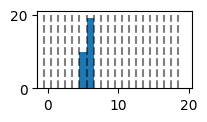

In [50]:
plt.figure(figsize=(2,1)) 
plt.hist(i_freq_max_diff_MEG[selected_regions_MEG],bins=np.array([i for i in range(20)])+0.5)
plt.vlines([i-0.5 for i in range(20)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)
frequiMI_MEG[[6,7,8]]
# the maximum differencefor subject 2 is found at freqs with indexes 6,7,8

In [14]:
frequiMI_MEG

array([ 5.        ,  5.83333333,  6.66666667,  7.5       ,  8.33333333,
        9.16666667, 10.        , 10.83333333, 11.66666667, 12.5       ,
       13.33333333, 14.16666667, 15.        , 15.83333333, 16.66666667,
       17.5       , 18.33333333, 19.16666667, 20.        , 20.83333333,
       21.66666667, 22.5       , 23.33333333, 24.16666667, 25.        ,
       25.83333333, 26.66666667, 27.5       , 28.33333333, 29.16666667,
       30.        ])

In [51]:
min_freq_frature_MEG = 8
max_freq_feature_MEG = 14
start_freq_idx_MEG = np.where(frequiMI_MEG>=min_freq_frature_MEG)[0][0]
end_freq_idx_MEG = np.where(frequiMI_MEG<=max_freq_feature_MEG)[0][-1]

In [52]:
wpsdRest_ROIs_freqs_MEG = wpsdRest_MEG[:,selected_regions_MEG,start_freq_idx_MEG:end_freq_idx_MEG]
wpsdMI_ROIs_freqs_MEG = wpsdMI_MEG[:,selected_regions_MEG,start_freq_idx_MEG:end_freq_idx_MEG]
wpsdRest_ROIs_freqs_MEG.shape

(94, 34, 6)

In [53]:
# as features i chose the max and the maen of selected_ROIs in freqs 8.3 to 13.3
features_MI_MEG = np.concatenate((wpsdMI_ROIs_freqs_MEG.mean(axis=-1,keepdims=True),
                              wpsdMI_ROIs_freqs_MEG.max(axis=-1,keepdims=True)),
                              axis=-1)
print(features_MI_MEG.shape)
features_MI_MEG = features_MI_MEG.reshape(94,-1)

features_Rest_MEG = np.concatenate((wpsdRest_ROIs_freqs_MEG.mean(axis=-1,keepdims=True),
                              wpsdRest_ROIs_freqs_MEG.max(axis=-1,keepdims=True)),
                              axis=-1)
features_Rest_MEG = features_Rest_MEG.reshape(94,-1)

features_MI_MEG.reshape(94,-1).shape
# for each trial i have mean and max of each ROI: 2 features for each of the 34 ROI:
# for each trial i have 68 features (both for Rest and MI tasks)

(94, 34, 2)


(94, 68)

In [54]:
features_MEG = np.concatenate((features_Rest_MEG,features_MI_MEG),axis=0)
labels_MEG = np.array([0 for i in range (96)] + [1 for i in range (96)]) # 0 for Rest, 1 for MI
features_MEG.shape


(188, 68)

In [60]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

kf = KFold(n_splits=5, shuffle=True, random_state=264)

fold_accuracies = []
fold_confusions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features_MEG)):
    print(f"\n----- Fold {fold_idx+1} -----")

    X_train, X_val = features_MEG[train_idx], features_MEG[val_idx]
    y_train, y_val = labels_MEG[train_idx], labels_MEG[val_idx]

    # StandardScaler:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    # LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)

    # Predict on validation
    y_pred = lda.predict(X_val_scaled)

    # Accuracy
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies.append(acc)

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_confusions.append(cm)

    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
    print(cm)

# Summary
print("==================================")
print("Mean accuracy:", np.mean(fold_accuracies))
print("Std accuracy:", np.std(fold_accuracies))




----- Fold 1 -----
Fold 1 accuracy: 0.6842, Confusion matrix:
[[16  4]
 [ 8 10]]

----- Fold 2 -----
Fold 2 accuracy: 0.6842, Confusion matrix:
[[ 9  5]
 [ 7 17]]

----- Fold 3 -----
Fold 3 accuracy: 0.7105, Confusion matrix:
[[15  7]
 [ 4 12]]

----- Fold 4 -----
Fold 4 accuracy: 0.7568, Confusion matrix:
[[12  5]
 [ 4 16]]

----- Fold 5 -----
Fold 5 accuracy: 0.7297, Confusion matrix:
[[17  6]
 [ 4 10]]
Mean accuracy: 0.7130867709815079
Std accuracy: 0.027778720907503034


In [59]:
from sklearn.svm import SVC 

train_models(features,labels, method=SVC, seed=267)


----- Fold 1 -----
Fold 1 accuracy: 0.6316, Confusion matrix:
[[14  8]
 [ 6 10]]

----- Fold 2 -----
Fold 2 accuracy: 0.6579, Confusion matrix:
[[ 9  8]
 [ 5 16]]

----- Fold 3 -----
Fold 3 accuracy: 0.7368, Confusion matrix:
[[18  5]
 [ 5 10]]

----- Fold 4 -----
Fold 4 accuracy: 0.7297, Confusion matrix:
[[12  5]
 [ 5 15]]

----- Fold 5 -----
Fold 5 accuracy: 0.7297, Confusion matrix:
[[10  5]
 [ 5 17]]

Mean accuracy: 0.6971550497866288
Std accuracy: 0.04367809359405058


([SVC(), SVC(), SVC(), SVC(), SVC()],
 [array([  7,  11,  16,  18,  26,  41,  49,  51,  60,  61,  62,  65,  72,
          74,  75,  76,  77,  81,  84,  86,  87,  93, 104, 105, 108, 111,
         117, 124, 133, 137, 146, 151, 165, 166, 167, 173, 181, 187]),
  array([  1,   3,   9,  19,  22,  23,  25,  27,  28,  36,  37,  38,  54,
          59,  69,  88,  89,  94,  96, 103, 106, 110, 113, 114, 116, 118,
         120, 123, 128, 129, 144, 150, 154, 156, 169, 172, 175, 176]),
  array([  5,   8,  14,  15,  20,  21,  29,  31,  35,  40,  44,  45,  55,
          56,  63,  64,  67,  70,  71,  80,  83,  85,  91,  99, 121, 131,
         134, 136, 138, 139, 140, 148, 153, 158, 164, 171, 178, 184]),
  array([  2,   4,   6,  10,  13,  24,  30,  32,  33,  34,  42,  43,  48,
          50,  68,  73,  78,  97,  98, 101, 102, 107, 112, 119, 125, 126,
         127, 141, 142, 155, 157, 160, 162, 170, 174, 177, 183]),
  array([  0,  12,  17,  39,  46,  47,  52,  53,  57,  58,  66,  79,  82,
          90,  92

# Integrate MEG EEG

In [2]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
subject_index=2

print(f"\n\n Subject {subject_index}")

data_2_MI_EEG  = read_subject(data_folder, "EEG", "MI",subject_index)
data_2_Rest_EEG = read_subject(data_folder, "EEG", "Baseline",subject_index)

data_2_MI_MEG  = read_subject(data_folder, "MEG", "MI",subject_index)
data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250



 Subject 2


In [ ]:
fmin=3
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

# miff = 8
# maff = 14
nbs=30

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

#  return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions
Feat_extraction_EEG = extract_features_more_bands(data_2_MI_EEG, data_2_Rest_EEG, 
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, selected_regions_EEG = Feat_extraction_EEG

Feat_extraction_MEG = extract_features_more_bands(data_2_MI_MEG, data_2_Rest_MEG,
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_MEG,Feat_Rest_MEG, labls_MI_MEG,labls_Rest_MEG, selected_regions_MEG = Feat_extraction_MEG

Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)


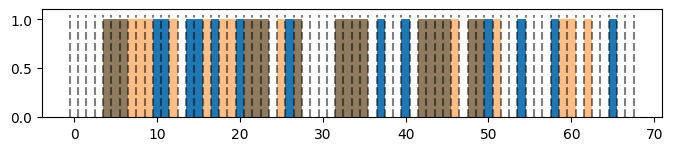

In [8]:
# see which regions have been chosen
plt.figure(figsize=(8,1.4)) 
a,b,c = plt.hist(selected_regions_EEG, bins=[i-0.5 for i in range(69)])
a,b,c = plt.hist(selected_regions_MEG, bins=[i-0.5 for i in range(69)],alpha=0.5)
plt.vlines([i-0.5 for i in range(69)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)

In [9]:
all_selected_ROIs = [i for i in selected_regions_EEG if i not in selected_regions_MEG]
all_selected_ROIs = all_selected_ROIs + [i for i in selected_regions_MEG]
#all_selected_ROIs = [i for i in selected_regions_EEG if i in selected_regions_MEG]

Both_color = "orange"; EEG_color = "red"; MEG_color = "yellow"
colors = [
    Both_color if (i in selected_regions_MEG and i in selected_regions_EEG)
    else MEG_color if i in selected_regions_MEG
    else EEG_color
    for i in all_selected_ROIs
]


In [15]:
plot_brain(all_selected_ROIs, brain_object_dict={"title":"EEG","hemi": "both"}, colors=colors)

Using pyvistaqt 3d backend.
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


In [12]:
Features_MI = np.concatenate((Feat_MI_EEG,Feat_MI_MEG), axis=1)
Features_Rest = np.concatenate((Feat_Rest_EEG,Feat_Rest_MEG), axis=1)
Features = np.concatenate((Features_MI,Features_Rest),axis=0)
Labels = np.concatenate((labls_MI_EEG,labls_Rest_EEG))
Feat_MI_MEG.shape, Features_MI.shape, Features.shape, labls_MI_EEG.shape, Labels.shape

((96, 180), (96, 360), (192, 360), (96,), (192,))

In [18]:
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier
training = train_models(Features,Labels,
                        method=RandomForestClassifier, 
                        seed=537, verbose=True)



----- Fold 1 -----
Fold 1 accuracy: 0.8718, Confusion matrix:
[[18  3]
 [ 2 16]]

----- Fold 2 -----
Fold 2 accuracy: 0.8974, Confusion matrix:
[[19  2]
 [ 2 16]]

----- Fold 3 -----
Fold 3 accuracy: 0.8947, Confusion matrix:
[[15  2]
 [ 2 19]]

----- Fold 4 -----
Fold 4 accuracy: 0.9737, Confusion matrix:
[[16  1]
 [ 0 21]]

----- Fold 5 -----
Fold 5 accuracy: 0.9211, Confusion matrix:
[[19  1]
 [ 2 16]]

Mean accuracy: 0.9117408906882591
Std accuracy: 0.034678922464716114


Mean accuracy: 0.9117408906882591
Std accuracy: 0.034678922464716114

In [ ]:
print(f"\n\n Subject {subject_index}")
data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)
#####################################################################################################################
fmin=3
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

#  return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions
Feat_extraction_EEG = extract_features_more_bands(data_2_MI_EEG, data_2_Rest_EEG, 
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, selected_regions_EEG = Feat_extraction_EEG

Feat_extraction_MEG = extract_features_more_bands(data_2_MI_MEG, data_2_Rest_MEG, 
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, selected_regions_MEG = Feat_extraction_MEG

Features_MI = np.concatenate((Feat_MI_EEG,Feat_MI_MEG), axis=1)
Features_Rest = np.concatenate((Feat_Rest_EEG,Feat_Rest_MEG), axis=1)
Features = np.concatenate((Features_MI,Features_Rest))
Labels = np.concatenate((labls_MI_EEG,labls_Rest_EEG))
#print(Feat_MI_MEG.shape, Features_MI.shape, Features.shape, labls_MI_EEG.shape, Labels.shape)
#####################################################################################################################

training = train_models(Features,Labels,
                        method=RandomForestClassifier, 
                        seed=537,verbose=True)



 Subject 2
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)

----- Fold 1 -----
Fold 1 accuracy: 0.8718, Confusion matrix:
[[18  3]
 [ 2 16]]

----- Fold 2 -----
Fold 2 accuracy: 0.8974, Confusion matrix:
[[19  2]
 [ 2 16]]

----- Fold 3 -----
Fold 3 accuracy: 0.8947, Confusion matrix:
[[15  2]
 [ 2 19]]

----- Fold 4 -----
Fold 4 accuracy: 0.9737, Confusion matrix:
[[16  1]
 [ 0 21]]

----- Fold 5 -----
Fold 5 accuracy: 0.9211, Confusion matrix:
[[19  1]
 [ 2 16]]

Mean accuracy: 0.9117408906882591
Std accuracy: 0.034678922464716114


# Investigate freq max difference Rest MI for each subjects

### Division in standard bands

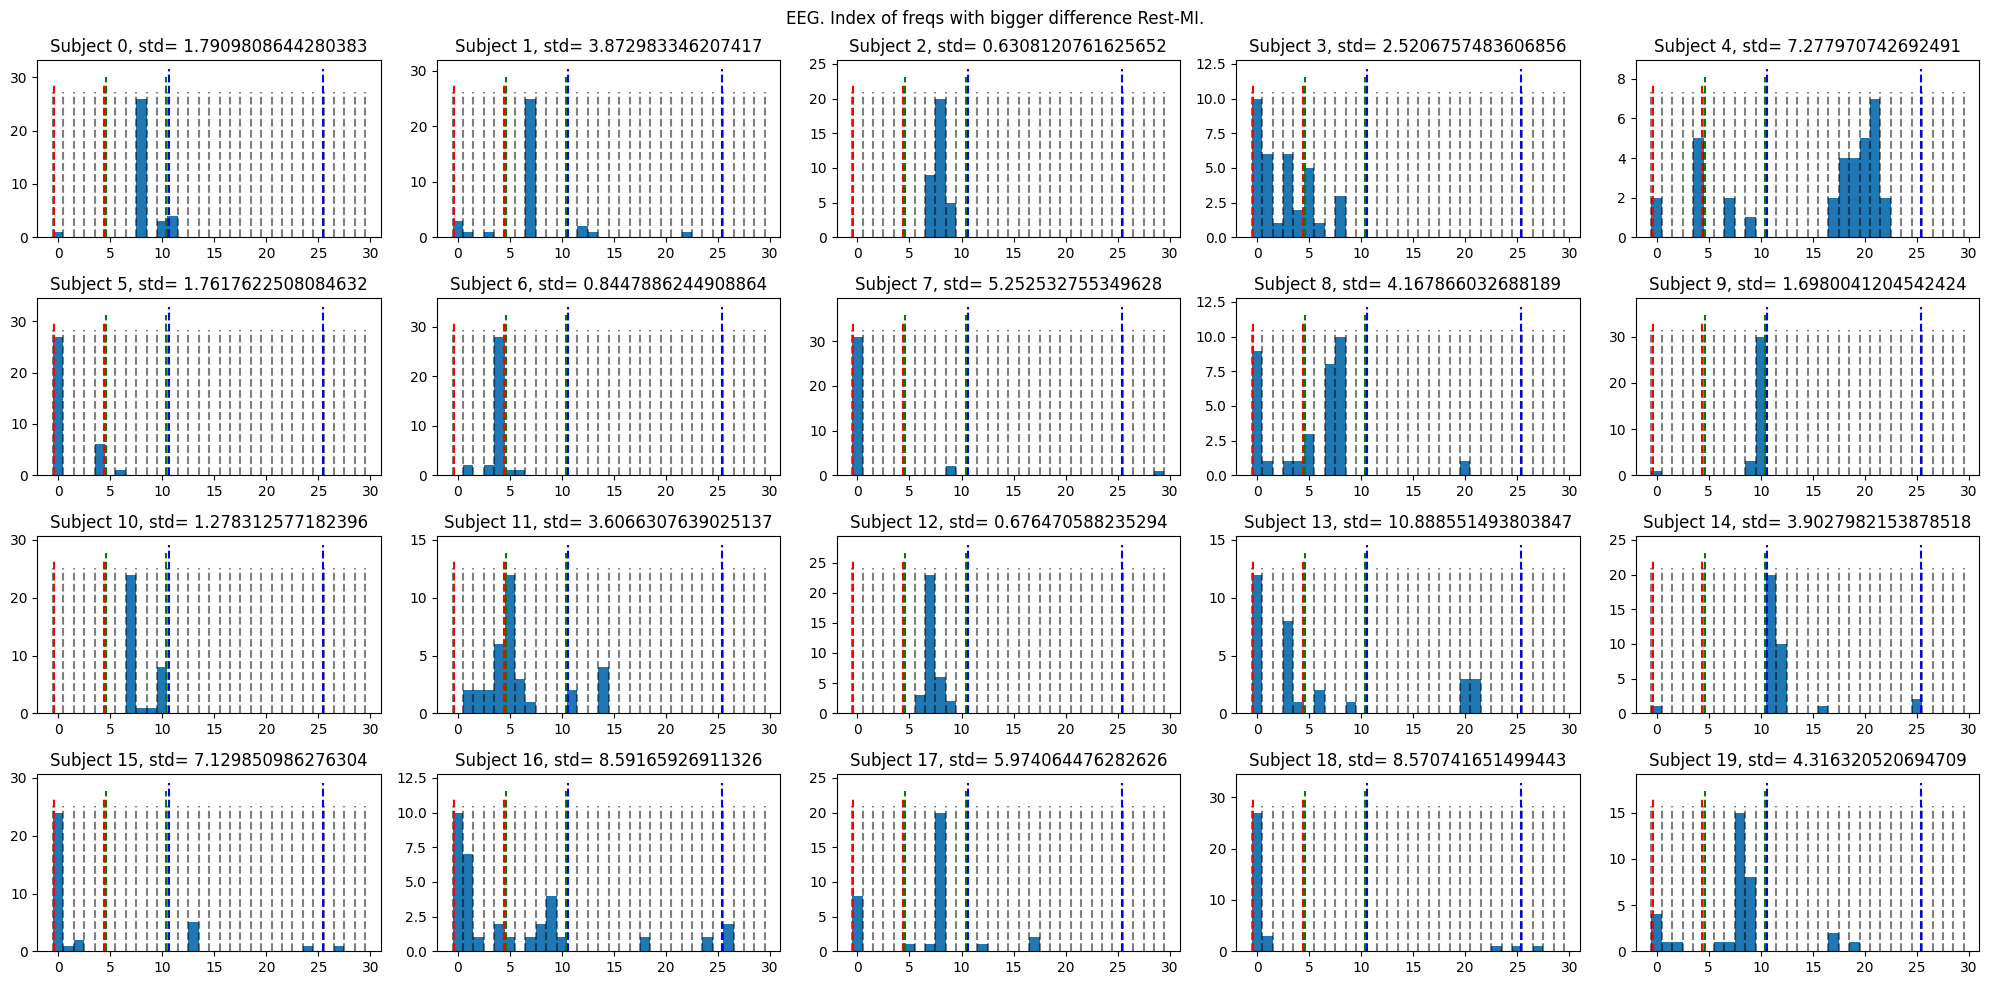

[ 7.5         8.33333333  9.16666667 10.         10.83333333 11.66666667
 12.5       ]


In [ ]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

# My frequency sampling
sfreq = 250

# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)
nregions = 34 

fmin=3
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap, "verbose":False}

fig, axes = plt.subplots(4, 5, figsize=(20, 10))  
axes = axes.flatten()  
ids_max=[]
for subject_index in range(20):
    data_2_MI = read_subject(data_folder, "EEG", "MI",subject_index)
    data_2_Rest = read_subject(data_folder, "Rest", "MI",subject_index)

    wpsdMI, frequiMI = psd_array_welch(data_2_MI[:,:,stime:-etime], **kargs )
    wpsdRest, frequiRest = psd_array_welch(data_2_Rest[:,:,stime:-etime], **kargs )

    wpsdRest.shape

    # selecting the ROIs where the difference between MI and Rest is max 

    i_freq_max_rest=[] # indici delle frequenze di dove é il massimo
    i_freq_max_diff=[] # .... where i find the max of diff
    max_rest=[]
    max_diff_perc=[] # max of the difference reported in percentage, not the maximum of the percentage difference

    for roi in range(68):
        wpsdMI_1ROI =wpsdMI[:,roi,:]
        wpsdRest_1ROI =wpsdRest[:,roi,:]
        wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)
        wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)
        
        max_rest.append(np.max(wpsd_Rest_mean))
        max_diff_perc.append(np.max(wpsd_Rest_mean-wpsd_MI_mean)/max_rest[-1])

        i_freq_max_rest.append(np.argmax(wpsd_Rest_mean))
        i_freq_max_diff.append(np.argmax(wpsd_Rest_mean-wpsd_MI_mean))

    i_freq_max_diff=np.array(i_freq_max_diff)
    np.argsort(max_diff_perc) # from smaller to bigger
    # I choose the nregions where I have the greatest difference between MI and Rest 
    # (but being careful to include the Interesting_regions)
    
    selected_regions = [i for i in Interesting_regions]
    for i in range(68):
        if np.argsort(max_diff_perc)[-i-1] not in selected_regions:
            selected_regions.append(int(np.argsort(max_diff_perc)[-i-1]))
        if len(selected_regions) >= nregions:
            break
    ids_max.append(i_freq_max_diff[selected_regions])        


    ax = axes[subject_index]  # select the subplot for this subject
    ax.hist(i_freq_max_diff[selected_regions], bins=np.arange(31)-0.5)
    ax.vlines([i-0.5 for i in range(31)], *ax.get_ylim(), colors="black", linestyles="--", alpha=0.5)
    min_freqs=[4,8,12]
    max_freqs=[8,12,30]

    start_freq_idx = [np.where(frequiMI>=min_freqs[i])[0][0] for i in range(len(min_freqs))]
    end_freq_idx = [np.where(frequiMI<=max_freqs[i])[0][-1] for i in range(len(max_freqs))]
    for i,color in enumerate(["red","green","blue"]):

        ax.vlines([start_freq_idx[i]-0.4, end_freq_idx[i]+0.4], *ax.get_ylim(), colors=color, linestyles="--")

    std_=np.array(i_freq_max_diff[selected_regions]).std()
    ax.set_title(f"Subject {subject_index}, std= {std_}")
    
plt.suptitle("EEG. Index of freqs with bigger difference Rest-MI.")
plt.tight_layout()
plt.show()

print(frequiMI[[4,5,6,7,8,9,10]])

### Frequencies personalized

In [1]:
freq_personalized = {"subject_0":[9,14.5],
                     "subject_1":[8,12],
                     "subject_2":[8,13.5],
                     "subject_3":[4,9.5],
                     "subject_4":[18,23.5],
                     "subject_5":[4,9.5],
                     "subject_6":[4,9.5],
                     "subject_7":[4,9.5],
                     "subject_8":[4,12],
                     "subject_9":[9.5,15.5],
                     "subject_10":[9,14.5],
                     "subject_11":[4,10.5],
                     "subject_12":[8,13.5],
                     "subject_13":[4,10.],
                     "subject_14":[12,18],
                     "subject_15":[4,8],
                     "subject_16":[4,13],
                     "subject_17":[4,12],
                     "subject_18":[4,9.5],
                     "subject_19":[4,12.5],
}

subject_0 trial_78 has wrong shape ((2,))
subject_0 trial_79 has wrong shape ((2,))
subject_0 trial_80 has wrong shape ((2,))
subject_0 trial_81 has wrong shape ((2,))
subject_0 trial_82 has wrong shape ((2,))
subject_0 trial_83 has wrong shape ((2,))
subject_0 trial_84 has wrong shape ((2,))
subject_0 trial_85 has wrong shape ((2,))
subject_0 trial_86 has wrong shape ((2,))
subject_0 trial_87 has wrong shape ((2,))
subject_0 trial_88 has wrong shape ((2,))
subject_0 trial_89 has wrong shape ((2,))
subject_0 trial_90 has wrong shape ((2,))
subject_0 trial_91 has wrong shape ((2,))
subject_0 trial_92 has wrong shape ((2,))
subject_0 trial_93 has wrong shape ((2,))
subject_0 trial_94 has wrong shape ((2,))
subject_0 trial_95 has wrong shape ((2,))
subject_0 trial_78 has wrong shape ((2,))
subject_0 trial_79 has wrong shape ((2,))
subject_0 trial_80 has wrong shape ((2,))
subject_0 trial_81 has wrong shape ((2,))
subject_0 trial_82 has wrong shape ((2,))
subject_0 trial_83 has wrong shape

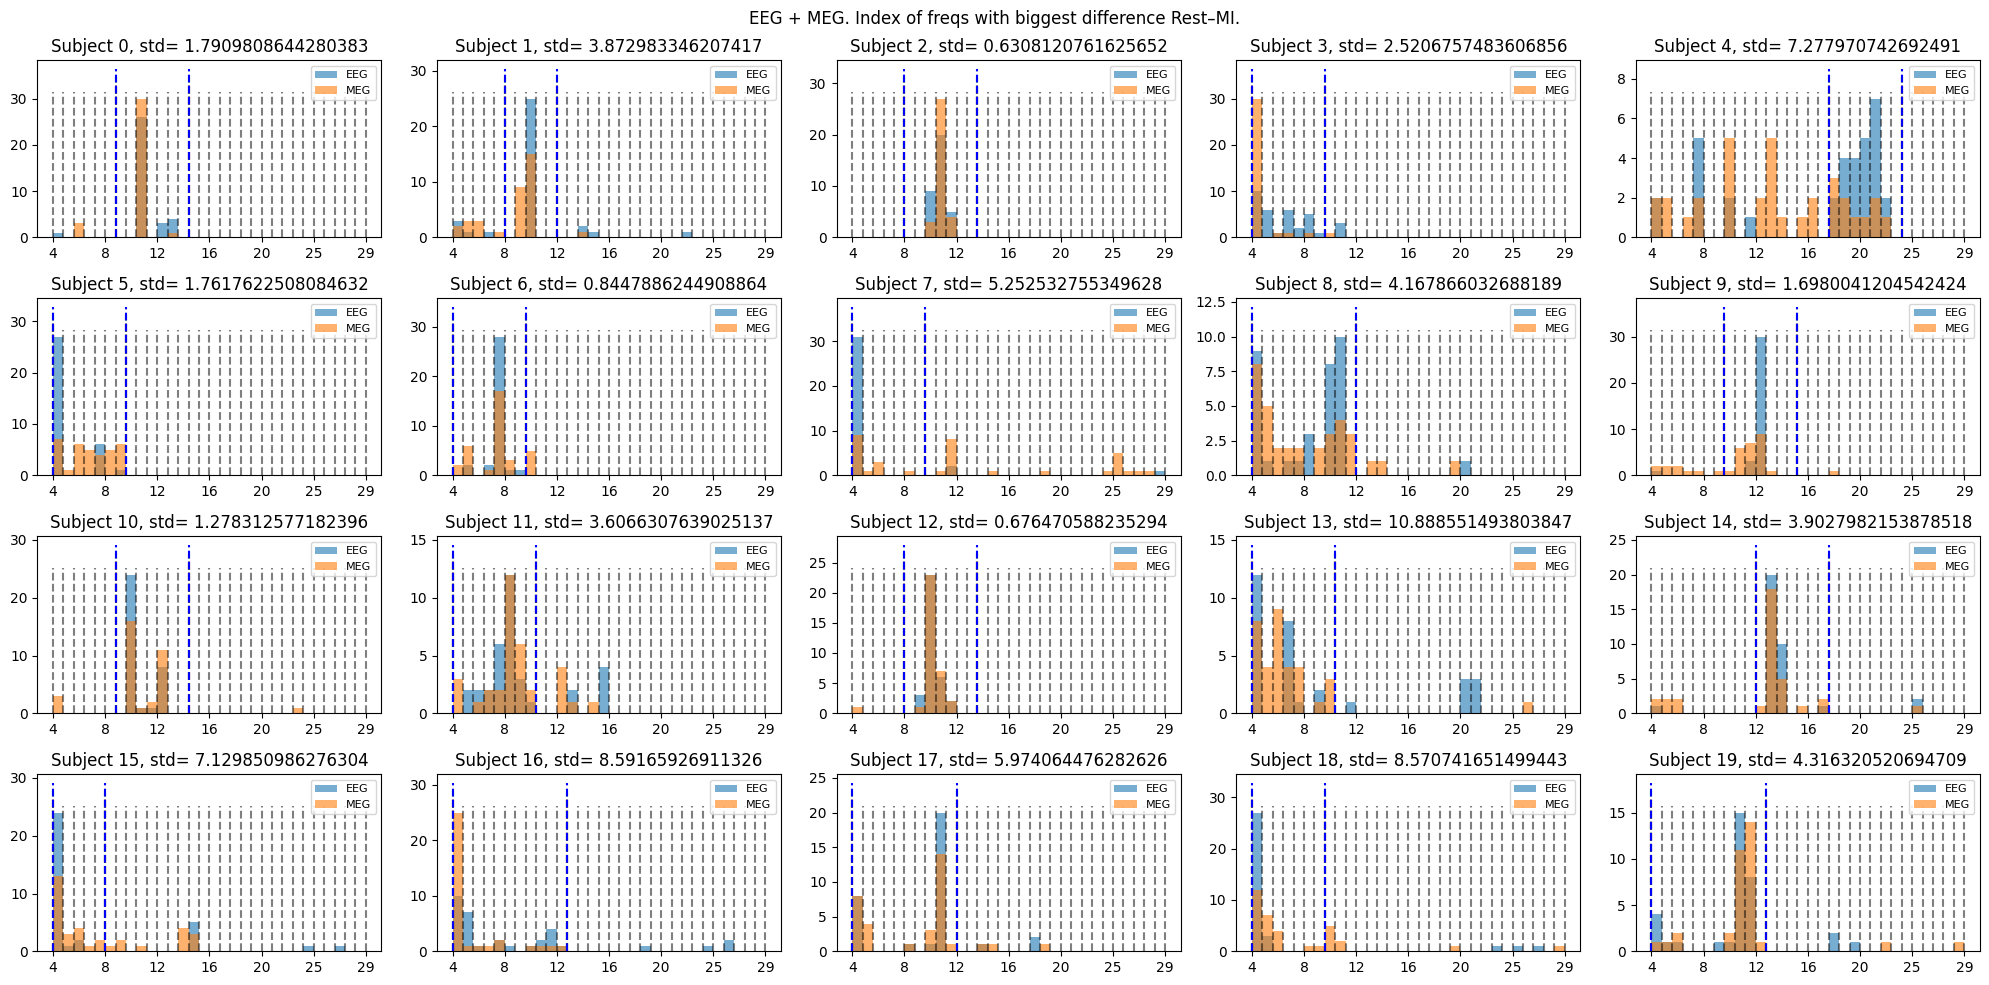

In [ ]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

Interesting_regions = [4, 5, 32, 33, 44, 45, 48, 49]

Good_subjects = [0, 2, 5, 9, 12, 14]
Ok_subjects = [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects,
                 "Ok_subjects": Ok_subjects,
                 "Other_subjects": Other_subjects}

data_folder="/Users/giovanni.messuti/Desktop/BCI_Project/Data/"

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, saveresults_pickle

# My frequency sampling
sfreq = 250

# Welch parameters
nregions = 34
fmin = 3
fmax = 30
n_per_seg = 250
n_fft = n_per_seg + 50
n_overlap = n_per_seg // 2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {
    "sfreq": sfreq,
    "fmin": fmin,
    "fmax": fmax,
    "n_per_seg": n_per_seg,
    "n_fft": n_fft,
    "n_overlap": n_overlap,
    "verbose": False
}

fig, axes = plt.subplots(4, 5, figsize=(20, 10))
axes = axes.flatten()

ids_max = []

for subject_index in range(20):

    # ---- Load EEG ----
    data_2_MI = read_subject(data_folder, "EEG", "MI", subject_index)
    data_2_Rest = read_subject(data_folder, "EEG", "Baseline", subject_index)

    # ---- Load MEG ----
    data_2_MI_MEG = read_subject(data_folder, "MEG", "MI", subject_index)
    data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline", subject_index)

    # ---- EEG PSD ----
    wpsdMI, frequiMI = psd_array_welch(data_2_MI[:, :, stime:-etime], **kargs)
    wpsdRest, _ = psd_array_welch(data_2_Rest[:, :, stime:-etime], **kargs)

    # ---- Select important EEG regions ----
    i_freq_max_rest = []
    i_freq_max_diff = []
    max_diff_perc = []

    for roi in range(68):
        MI_roi = wpsdMI[:, roi, :]
        Rest_roi = wpsdRest[:, roi, :]

        MI_mean = MI_roi.mean(axis=0)
        Rest_mean = Rest_roi.mean(axis=0)

        max_rest_val = np.max(Rest_mean)
        max_diff_perc.append(np.max(Rest_mean - MI_mean) / max_rest_val)

        i_freq_max_rest.append(np.argmax(Rest_mean))
        i_freq_max_diff.append(np.argmax(Rest_mean - MI_mean))

    i_freq_max_diff = np.array(i_freq_max_diff)

    # Keep EEG-selected regions
    selected_regions = [i for i in Interesting_regions]
    order = np.argsort(max_diff_perc)

    for i in range(68):
        idx = int(order[-i-1])
        if idx not in selected_regions:
            selected_regions.append(idx)
        if len(selected_regions) >= nregions:
            break

    ids_max.append(i_freq_max_diff[selected_regions])

    eeg_freq_idx = i_freq_max_diff[selected_regions]

    # ---- MEG PSD ----
    wpsdMI_MEG, _ = psd_array_welch(data_2_MI_MEG[:, :, stime:-etime], **kargs)
    wpsdRest_MEG, _ = psd_array_welch(data_2_Rest_MEG[:, :, stime:-etime], **kargs)

    i_freq_max_diff_meg = []
    max_diff_perc_meg = []

    for roi in range(68):
        MI_roi = wpsdMI_MEG[:, roi, :]
        Rest_roi = wpsdRest_MEG[:, roi, :]

        MI_mean = MI_roi.mean(axis=0)
        Rest_mean = Rest_roi.mean(axis=0)

        max_rest_val = np.max(Rest_mean)
        max_diff_perc_meg.append(np.max(Rest_mean - MI_mean) / max_rest_val)

        i_freq_max_diff_meg.append(np.argmax(Rest_mean - MI_mean))

    i_freq_max_diff_meg = np.array(i_freq_max_diff_meg)

    meg_freq_idx = i_freq_max_diff_meg[selected_regions]

    # ---- PLOT ----
    ax = axes[subject_index]

    # EEG histogram
    ax.hist(eeg_freq_idx, bins=np.arange(31), alpha=0.6, label="EEG")

    # MEG histogram
    ax.hist(meg_freq_idx, bins=np.arange(31), alpha=0.6, label="MEG")

    # Vertical guidelines
    ax.vlines(np.arange(31), *ax.get_ylim(), colors="black", linestyles="--", alpha=0.5)

    # Bands markers
    min_freqs = [4, 8, 13]
    max_freqs = [8, 13, 25]

    start_freq_idx = np.where(frequiMI>=freq_personalized[f"subject_{subject_index}"][0])[0][0]
    end_freq_idx = np.where(frequiMI<=freq_personalized[f"subject_{subject_index}"][-1])[0][-1]


    for i, color in enumerate(["red", "green", "blue"]):
        ax.vlines([start_freq_idx, end_freq_idx + 1],
                  *ax.get_ylim(), colors=color, linestyles="--")

    std_ = np.array(eeg_freq_idx).std()
    ax.set_title(f"Subject {subject_index}, std= {std_}")

    # X ticks
    positions = [0, 5, 10, 15, 20, 25, 30]
    ax.set_xticks(positions)
    ax.set_xticklabels([str(int(f)) for f in frequiMI[positions]])

    ax.legend(fontsize=8)

plt.suptitle("EEG + MEG. Index of freqs with biggest difference Rest-MI.")
plt.tight_layout()
plt.show()


# Consistence of selected regions among k-folds

### MyCriteria - Based on MaxDiff Rest-MI
- I am "averaging" (selecting) on frequency bins
- I am averaging among trials

This is why MyCriteria is more robust with respect to Multi T-Test on whole Power Spectra 


In [15]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch_select_regions(data_2_MI, data_2_Rest, sfreq, important_regions=[], select_regions=False,
                                                        kargs_welch={"fmin":8, "fmax":30})

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
            regions_selected = compute_welch_select_regions(wpsdMI=WMI[selected_idx[np.where(selected_idx<len(WMI))]], 
                                                            wpsdRest=WRe[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI)], 
                                                            frequiMI=FreqMI, important_regions=[], nbest_regions=quanteroi)
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple(regions_selected))
    pandadizio = pd.DataFrame.from_dict(dizio)
    pandadizio.to_pickle(filepath+f"_MyCriteria_{DataType}_among_{n_folds}_folds_training_selected_freq_8_30.pkl")




100%|██████████| 20/20 [00:26<00:00,  1.31s/it]


In [16]:
import pandas as pd
filepath = "/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/Selected_regions"
pandadizio=pd.read_pickle(filepath+f"_MyCriteria_EEG_among_5_folds_training_selected_freq_8_30.pkl")
pandadizio

,Subject,ROIs_fold_1,ROIs_fold_2,ROIs_fold_3,ROIs_fold_4,ROIs_fold_5
0,0,"(23, 15, 51, 14, 50, 59, 35, 58, 17, 22, 42, 6...","(23, 14, 22, 15, 50, 42, 58, 6, 17, 51, 35, 7,...","(23, 15, 51, 17, 14, 59, 22, 58, 42, 50, 35, 6...","(23, 15, 14, 51, 17, 22, 59, 50, 58, 35, 6, 42...","(23, 15, 14, 22, 17, 35, 42, 50, 6, 58, 51, 27..."
1,1,"(67, 61, 43, 59, 42, 51, 17, 26, 32, 50, 19, 7...","(67, 61, 43, 59, 42, 51, 26, 7, 17, 1, 30, 62,...","(67, 61, 43, 59, 1, 51, 17, 32, 50, 7, 42, 20,...","(67, 61, 43, 59, 42, 17, 1, 26, 51, 21, 32, 62...","(67, 61, 43, 59, 42, 32, 51, 26, 1, 17, 7, 20,..."
2,2,"(42, 14, 43, 26, 23, 27, 22, 6, 48, 21, 4, 15,...","(42, 14, 43, 26, 23, 48, 27, 6, 22, 4, 10, 11,...","(14, 42, 23, 43, 26, 48, 4, 27, 22, 10, 11, 21...","(42, 23, 43, 14, 26, 27, 22, 6, 21, 48, 20, 32...","(42, 43, 14, 23, 6, 27, 48, 26, 32, 4, 22, 21,..."
3,3,"(7, 22, 23, 15, 51, 50, 59, 45, 43, 6, 32, 33,...","(7, 22, 23, 15, 51, 32, 50, 59, 45, 33, 43, 6,...","(7, 22, 23, 32, 43, 15, 56, 51, 33, 50, 14, 62...","(7, 22, 23, 15, 51, 50, 59, 43, 14, 33, 6, 48,...","(7, 22, 23, 51, 15, 50, 43, 14, 59, 32, 45, 6,..."
4,4,"(16, 30, 22, 10, 7, 12, 48, 57, 32, 56, 44, 4,...","(22, 7, 16, 30, 10, 57, 48, 32, 56, 47, 12, 44...","(7, 22, 16, 30, 62, 48, 64, 57, 12, 4, 14, 44,...","(16, 30, 10, 48, 44, 4, 12, 22, 47, 55, 64, 32...","(22, 16, 30, 7, 57, 48, 58, 12, 62, 4, 32, 44,..."
5,5,"(7, 6, 4, 27, 33, 43, 59, 46, 56, 20, 50, 51, ...","(4, 7, 6, 57, 38, 33, 23, 27, 59, 24, 43, 46, ...","(4, 6, 46, 7, 43, 27, 38, 22, 23, 24, 20, 57, ...","(4, 6, 33, 43, 7, 46, 40, 22, 27, 23, 20, 58, ...","(6, 7, 4, 59, 33, 40, 43, 23, 27, 51, 46, 58, ..."
6,6,"(0, 36, 48, 16, 30, 34, 25, 50, 56, 66, 29, 54...","(48, 0, 36, 16, 34, 14, 30, 25, 66, 12, 44, 29...","(36, 0, 48, 16, 34, 58, 45, 30, 54, 50, 14, 24...","(36, 0, 25, 12, 16, 48, 64, 54, 56, 14, 34, 50...","(0, 48, 16, 36, 56, 54, 34, 50, 12, 14, 30, 32..."
7,7,"(7, 42, 43, 59, 27, 45, 6, 15, 22, 49, 14, 26,...","(7, 42, 43, 59, 27, 45, 22, 49, 6, 15, 32, 57,...","(59, 15, 7, 49, 45, 42, 43, 57, 5, 6, 53, 27, ...","(7, 42, 15, 43, 59, 6, 27, 22, 5, 57, 49, 14, ...","(7, 59, 15, 42, 43, 49, 45, 27, 6, 57, 5, 22, ..."
8,8,"(15, 23, 26, 50, 27, 51, 34, 0, 35, 22, 17, 13...","(26, 27, 23, 15, 34, 35, 51, 50, 13, 0, 22, 17...","(15, 50, 51, 27, 26, 34, 23, 35, 58, 0, 17, 13...","(15, 51, 23, 50, 26, 27, 34, 0, 35, 22, 58, 17...","(15, 23, 50, 51, 26, 27, 34, 58, 35, 17, 7, 43..."
9,9,"(65, 53, 55, 31, 32, 10, 52, 8, 11, 29, 23, 18...","(65, 55, 53, 10, 31, 11, 29, 52, 59, 18, 61, 2...","(65, 55, 10, 53, 59, 11, 31, 30, 23, 32, 51, 6...","(55, 53, 65, 10, 29, 11, 31, 59, 52, 51, 18, 2...","(55, 53, 65, 10, 52, 29, 11, 31, 18, 59, 61, 3..."


Text(0.5, 1.0, 'fixed subject, ranking in 5 kfolds')

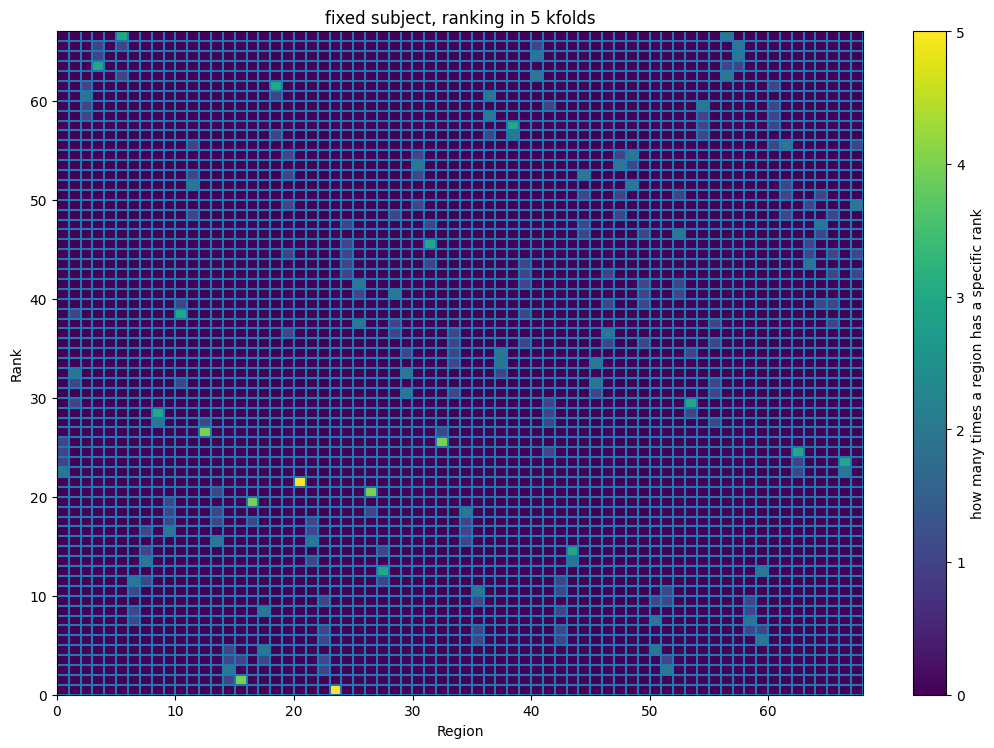

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap

subject=0
fino_a = 68

binx = np.arange(69)-0.001
biny = np.arange(fino_a)-0.001

rankings = []
for fold in range(1,len(pandadizio.keys())):
    rankings.append(list(pandadizio.iloc[subject,fold][:fino_a]))

rankings = np.array(rankings)
n_folds = rankings.shape[0]
plt.figure(figsize=(13,3.8*fino_a/30))
plt.hist2d(rankings.flatten(),np.tile(np.arange(fino_a), (n_folds,1)).flatten(),bins=(binx,biny))
#plt.hist2d(pandadizio.iloc[subject,1][:fino_a],range(fino_a),bins=(binx,biny))
plt.vlines(binx,0,fino_a)
plt.hlines(biny,0,68)
plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"fixed subject, ranking in {len(rankings)} kfolds")

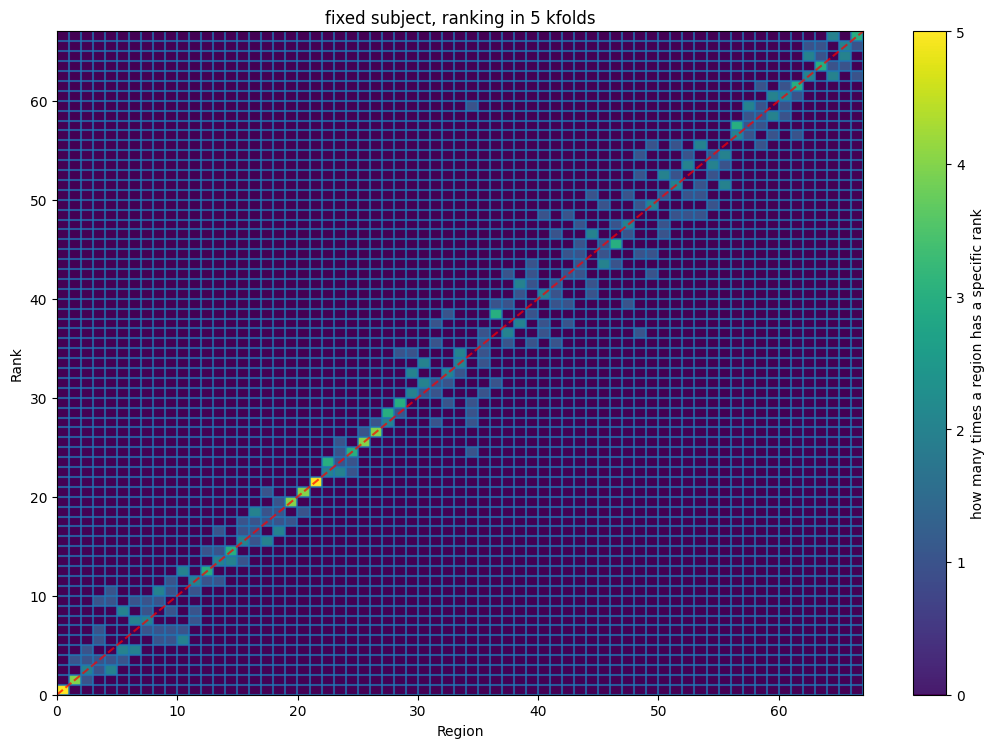

In [37]:
rankings_sorted, sorted_regions =  sort_rank(rankings)

plt.figure(figsize=(13,3.8*fino_a/30))

binx = np.arange(68)-0.001
biny = np.arange(fino_a)-0.001

mic = matplotlib.colormaps.get_cmap("viridis")
color0 = mic(0.)
other_colors = mic(np.linspace(0.07, 1., 1001))
colors = np.vstack([color0, other_colors])
cmap = ListedColormap(colors)

hist = plt.hist2d(
    rankings_sorted.flatten(),
    np.tile(np.arange(fino_a), (n_folds,1)).flatten(),
    bins=(binx, biny),
    cmap=cmap, vmin=0, vmax=len(rankings_sorted)  # ensures 6 discrete levels
)

coco = "C0"
plt.vlines(binx,0,fino_a,alpha=0.75,color=coco)
plt.hlines(biny,0,68,alpha=0.75,color=coco)

plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"fixed subject, ranking in {len(rankings_sorted)} kfolds")
plt.plot([0,68],[0,68],color="red",linestyle="--",alpha=0.7)

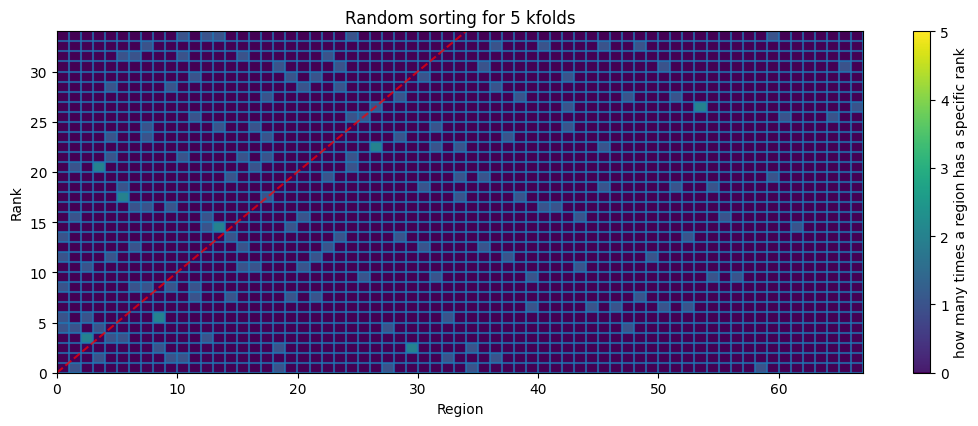

In [62]:
fino_a = 35
n_foldsSS = 5
random_rankings = np.array([np.random.permutation(np.arange(68)) for __ in range(n_foldsSS)])

rankings_random_sorted, sorted_random_regions =  sort_rank(random_rankings)

rankings_random_sorted = rankings_random_sorted[:,:fino_a]

plt.figure(figsize=(13,3.8*fino_a/30))

binx = np.arange(68)-0.001
biny = np.arange(fino_a)-0.001

mic = matplotlib.colormaps.get_cmap("viridis")
color0 = mic(0.)
other_colors = mic(np.linspace(0.07, 1., 1001))
colors = np.vstack([color0, other_colors])
cmap = ListedColormap(colors)

hist = plt.hist2d(
    rankings_random_sorted.flatten(),
    np.tile(np.arange(fino_a), (n_foldsSS,1)).flatten(),
    bins=(binx, biny),
    cmap=cmap, vmin=0, vmax=len(rankings_random_sorted)  # ensures 6 discrete levels
)

coco = "C0"
plt.vlines(binx,0,fino_a,alpha=0.75,color=coco)
plt.hlines(biny,0,68,alpha=0.75,color=coco)

plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"Random sorting for {len(rankings_random_sorted)} kfolds")
plt.plot([0,68],[0,68],color="red",linestyle="--",alpha=0.7)

### Multi T-test - on complete Power Spectra

In [ ]:
import pingouin as pg


import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

subject_index = 0
region = 33

data_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

sfreq = 250
pvalues=[]
power_MI, power_Rest, Freqs = compute_welch(data_MI,data_Rest)
for region in range(68):
    result = pg.multivariate_ttest(power_MI[:,region,:], power_Rest[:,region,:])
    pvalues.append(float(result.pval.values[0]))
# print(result)


In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=2
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

import math

round_sig = lambda x, sig=5: 0 if x == 0 else round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)

saveresults = True
filepath = "/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Pvalues_{fold+1}"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq)

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = val_idx
            pvalues = []
            for region in range(68):
                result = pg.multivariate_ttest(WMI[selected_idx[np.where(selected_idx<len(WMI))],region,:], 
                                               WRe[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI),region,:])
                pvalues.append(float(result.pval.values[0]))
            pvalues=np.array(pvalues)
            regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
            pvalues = pvalues[pvalues.argsort()]
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple([ int(_) for _ in regions_selected]))
            dizio[f"Pvalues_{fold_idx+1}"].append(tuple([round_sig(float(_),3) for _ in pvalues]))
    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MultiTtest_{DataType}_among_{n_folds}_folds_validation_selected_all_spectra.pkl")

100%|██████████| 20/20 [00:27<00:00,  1.35s/it]


### Multi T-test - on average of 2 bands

In [84]:
import pingouin as pg


import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

subject_index = 2
region = 33

data_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

sfreq = 250
pvalues=[]
power_MI, power_Rest, Freqs = compute_welch(data_MI,data_Rest, kargs_welch={"fmin":8, "fmax":30})
# for region in range(68):
#     result = pg.multivariate_ttest(power_MI[:,region,:], power_Rest[:,region,:])
#     pvalues.append(float(result.pval.values[0]))
# print(result)


In [107]:
np.concatenate((power_MI[:,:,np.where(Freqs<13)].mean(axis=-1),power_MI[:,:,np.where(Freqs>=13)].mean(axis=-1)),axis=-1)

array([[[1.75422192e-22, 8.90647046e-23],
        [1.05129860e-22, 4.67174046e-23],
        [2.09186183e-23, 9.71026449e-24],
        ...,
        [4.70087112e-22, 1.63851028e-22],
        [1.31678337e-22, 4.18197029e-23],
        [7.07367764e-23, 3.39920881e-23]],

       [[1.64047366e-22, 1.09254550e-22],
        [1.11724775e-22, 6.07507095e-23],
        [3.12260321e-23, 1.01926010e-23],
        ...,
        [2.02945381e-22, 1.93370135e-22],
        [8.43638051e-23, 3.73826245e-23],
        [6.46695493e-23, 4.49881751e-23]],

       [[1.26661545e-22, 9.80397035e-23],
        [7.44640538e-23, 5.40137064e-23],
        [2.09989902e-23, 7.75153702e-24],
        ...,
        [2.68590417e-22, 2.07447548e-22],
        [1.04148980e-22, 4.89455972e-23],
        [5.98760673e-23, 4.92707768e-23]],

       ...,

       [[2.78523853e-22, 1.69088942e-22],
        [2.58106137e-22, 7.01404331e-23],
        [3.36684383e-23, 3.08158900e-23],
        ...,
        [2.40451320e-21, 1.11145178e-21],
     

In [3]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
import pingouin as pg

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

import math

round_sig = lambda x, sig=5: 0 if x == 0 else round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)

saveresults = True
filepath = "/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Pvalues_{fold+1}"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq)

        mean_alph = np.concatenate((WMI[:,:,np.where(FreqMI<13)].mean(axis=-1),WMI[:,:,np.where(FreqMI>=13)].mean(axis=-1)),axis=-1)
        mean_beta = np.concatenate((WRe[:,:,np.where(FreqMI<13)].mean(axis=-1),WRe[:,:,np.where(FreqMI>=13)].mean(axis=-1)),axis=-1)

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(mean_alph))] + [0 for __ in range(len(mean_beta))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
            pvalues = []
            for region in range(68):
                result = pg.multivariate_ttest(mean_alph[selected_idx[np.where(selected_idx<len(mean_alph))],region,:], 
                                               mean_beta[selected_idx[np.where(selected_idx>=len(mean_alph))]-len(mean_alph),region,:])
                pvalues.append(float(result.pval.values[0]))
            pvalues=np.array(pvalues)
            regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
            pvalues = pvalues[pvalues.argsort()]
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple([ int(_) for _ in regions_selected]))
            dizio[f"Pvalues_{fold_idx+1}"].append(tuple([round_sig(float(_),3) for _ in pvalues]))
    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MultiTtest_on_mean_alpha_beta_{DataType}_among_{n_folds}_folds_training_selected.pkl")

100%|██████████| 20/20 [00:27<00:00,  1.37s/it]


### verify selection

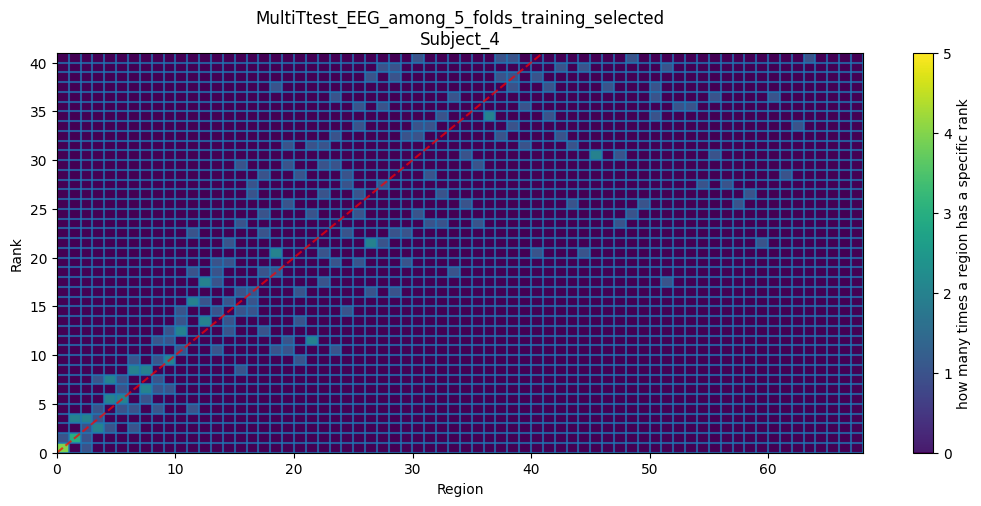

In [11]:
for subject_idx in range(4,5):
    plot_hist2d_selected_regions_folds("/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/" \
    "Selected_regions_MultiTtest_EEG_among_5_folds_training_selected.pkl",
                                subject=subject_idx, num_best_selected=41, plot_sorted=True, 
                                figtitle=f"MultiTtest_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                #save_path="/Users/giovanni.messuti/Desktop/BCI_Project/Images/" \
                                #f"Hist2d_region_selection/MultiTtest_EEG_among_5_folds_training_selected_subject_{subject_idx}.png",
                                )
None

In [ ]:
for subject_index in range(20):
    plot_hist2d_selected_regions_folds("/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/" \
        "Selected_regions_MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected.pkl",
                                    subject=subject_index, num_best_selected=68, plot_sorted=True, 
                                    figtitle=f"MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected\nSubject_{subject_index}",
                                    #save_path="/Users/giovanni.messuti/Desktop/BCI_Project/Images/" \
                                    #f"Hist2d_region_selection/MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected_subject_{subject_index}.png",
    )
None

In [ ]:
for subject_idx in range(20):
    plot_hist2d_selected_regions_folds("/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/" \
    "Selected_regions_MyCriteria_EEG_among_5_folds_training_selected_freq_8_30.pkl",
                                subject=subject_idx, num_best_selected=68, plot_sorted=True, 
                                figtitle=f"MyCriteria_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                #save_path="/Users/giovanni.messuti/Desktop/BCI_Project/Images/" \
                                #f"Hist2d_region_selection/MyCriteria_EEG_among_5_folds_training_selected_subject_{subject_idx}_freq_8_30.png"
                                )


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
patti = "/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/Selected_regions_MultiTtest_EEG_among_5_folds_training_selected.pkl"
Multi_T_test=pd.read_pickle(patti)
Multi_T_test

,Subject,ROIs_fold_1,Pvalues_1,ROIs_fold_2,Pvalues_2,ROIs_fold_3,Pvalues_3,ROIs_fold_4,Pvalues_4,ROIs_fold_5,Pvalues_5
0,0,"(21, 51, 15, 14, 26, 22, 47, 7, 42, 20, 43, 59...","(3.21e-10, 6.66e-10, 1.78e-09, 2.62e-09, 7e-09...","(23, 22, 15, 42, 20, 6, 14, 43, 21, 32, 26, 47...","(1.2e-11, 3.99e-11, 5.6e-11, 1.31e-10, 1.87e-1...","(22, 42, 26, 14, 15, 7, 6, 23, 44, 34, 21, 47,...","(1.11e-13, 5.42e-12, 6.25e-11, 1.63e-10, 4.83e...","(15, 14, 22, 42, 6, 23, 20, 47, 26, 21, 51, 2,...","(7.58e-12, 1.77e-11, 3.88e-11, 1.15e-09, 2.34e...","(22, 47, 7, 21, 14, 26, 15, 23, 32, 42, 20, 6,...","(1.93e-11, 2.87e-10, 3.48e-10, 1.06e-09, 1.94e..."
1,1,"(1, 31, 13, 9, 61, 35, 12, 43, 67, 21, 42, 26,...","(2.43e-13, 2.45e-10, 3.89e-08, 8.35e-08, 1.17e...","(1, 31, 61, 43, 35, 67, 21, 9, 27, 13, 59, 49,...","(8.79e-17, 2.72e-13, 5.12e-09, 8.21e-09, 6.6e-...","(1, 31, 43, 35, 61, 9, 67, 27, 26, 42, 59, 34,...","(1.02e-12, 8.01e-10, 4e-09, 2.18e-08, 2.39e-07...","(1, 31, 35, 67, 61, 13, 43, 9, 6, 34, 27, 12, ...","(2.15e-12, 1.47e-11, 2.81e-10, 1.03e-08, 1.36e...","(31, 1, 61, 9, 35, 67, 43, 27, 13, 21, 26, 34,...","(1.08e-12, 6.52e-12, 1.74e-09, 2.83e-08, 5.79e..."
2,2,"(32, 46, 14, 50, 33, 62, 48, 45, 51, 49, 44, 4...","(2.92e-13, 4.54e-13, 4.92e-13, 4.73e-12, 6.31e...","(32, 46, 50, 14, 45, 33, 44, 47, 49, 48, 51, 4...","(3.71e-16, 3.19e-15, 4.09e-13, 1.57e-11, 1.7e-...","(46, 32, 14, 50, 45, 44, 33, 4, 48, 62, 49, 51...","(6.22e-14, 1.45e-13, 8.33e-12, 2.02e-11, 9.37e...","(32, 46, 14, 62, 33, 50, 45, 49, 51, 4, 38, 47...","(3.54e-14, 7.85e-14, 3.77e-13, 1.54e-11, 5.5e-...","(46, 45, 32, 33, 14, 49, 50, 62, 4, 47, 15, 51...","(2.56e-15, 9.8e-14, 1.21e-13, 1.14e-12, 1.37e-..."
3,3,"(49, 41, 23, 22, 15, 60, 51, 67, 4, 44, 48, 63...","(2.87e-16, 4.65e-13, 1.43e-08, 1.75e-07, 3.06e...","(41, 49, 23, 22, 51, 15, 4, 21, 43, 39, 44, 14...","(1.49e-14, 2.49e-11, 1.25e-09, 7.68e-08, 1.1e-...","(41, 49, 23, 22, 15, 32, 4, 44, 14, 51, 7, 50,...","(2.02e-15, 2.6e-11, 4.89e-10, 5.3e-07, 1e-06, ...","(41, 49, 23, 22, 15, 51, 4, 7, 58, 48, 39, 43,...","(3.5e-14, 1.89e-10, 2.1e-09, 3.38e-08, 2.06e-0...","(41, 23, 49, 22, 15, 44, 14, 51, 7, 50, 45, 4,...","(1.27e-14, 2.27e-10, 2.59e-10, 7.91e-10, 4.08e..."
4,4,"(16, 12, 30, 26, 44, 42, 34, 48, 8, 58, 0, 11,...","(5.16e-09, 3.74e-08, 5.42e-07, 5.18e-06, 8.27e...","(26, 16, 58, 12, 30, 42, 48, 34, 8, 62, 22, 66...","(1.58e-07, 2.49e-07, 1.81e-06, 2.06e-06, 6.85e...","(16, 12, 26, 30, 48, 34, 8, 42, 58, 27, 11, 62...","(1.59e-09, 6.03e-09, 2.46e-08, 9.53e-08, 2.34e...","(16, 26, 42, 12, 34, 8, 62, 30, 58, 48, 10, 66...","(1.46e-09, 6.03e-09, 5.59e-07, 1.86e-06, 2.87e...","(16, 12, 30, 26, 58, 34, 8, 42, 64, 62, 63, 48...","(8e-12, 6.47e-10, 1.13e-09, 3.59e-09, 5.41e-08..."
5,5,"(4, 22, 20, 27, 12, 26, 42, 62, 17, 15, 16, 13...","(2.65e-15, 1.38e-10, 2.64e-10, 4.28e-10, 9.07e...","(4, 20, 62, 42, 22, 15, 32, 12, 43, 23, 26, 46...","(5.13e-15, 1.12e-10, 5.58e-09, 6.28e-09, 1.09e...","(4, 20, 46, 22, 62, 43, 42, 12, 27, 32, 0, 23,...","(2.16e-15, 2.07e-10, 2.72e-10, 1.1e-08, 1.9e-0...","(4, 22, 20, 42, 26, 62, 46, 23, 15, 43, 12, 16...","(2.61e-14, 2.6e-10, 6.86e-10, 3.73e-09, 6.13e-...","(4, 46, 22, 62, 42, 20, 32, 26, 12, 15, 43, 33...","(3.03e-14, 4.47e-10, 6.2e-09, 6.98e-09, 2.39e-..."
6,6,"(55, 32, 35, 43, 26, 17, 51, 14, 1, 25, 50, 59...","(3.58e-07, 1.44e-06, 2.42e-06, 2.95e-06, 5.5e-...","(26, 59, 18, 43, 10, 35, 50, 14, 32, 17, 55, 2...","(6.45e-08, 1.33e-06, 2.33e-06, 2.99e-06, 3.92e...","(14, 35, 50, 58, 51, 43, 27, 26, 30, 59, 48, 2...","(5.71e-09, 5.52e-08, 7.18e-08, 1.19e-06, 1.75e...","(55, 51, 35, 17, 14, 43, 48, 26, 29, 32, 1, 10...","(7.21e-08, 7.97e-08, 6.22e-07, 1.13e-06, 1.32e...","(35, 43, 26, 51, 14, 50, 62, 23, 7, 32, 55, 27...","(7.11e-08, 2.04e-07, 5.34e-07, 5.79e-07, 8.69e..."
7,7,"(32, 44, 46, 13, 6, 11, 14, 51, 67, 43, 41, 48...","(1.49e-07, 1.61e-06, 7.68e-06, 0.000133, 0.000...","(32, 44, 46, 13, 48, 14, 6, 45, 11, 35, 41, 63...","(2.39e-07, 1.35e-06, 3.08e-05, 4.05e-05, 5.23e...","

(array([ 1.,  0.,  2.,  1.,  0.,  1.,  2.,  0.,  3.,  3.,  0.,  1.,  5.,
         5.,  8.,  8., 10., 10.,  2.,  6.]),
 array([-14.59176003, -13.91195596, -13.23215189, -12.55234782,
        -11.87254375, -11.19273968, -10.51293561,  -9.83313154,
         -9.15332747,  -8.4735234 ,  -7.79371933,  -7.11391526,
         -6.43411119,  -5.75430712,  -5.07450305,  -4.39469898,
         -3.71489491,  -3.03509084,  -2.35528677,  -1.6754827 ,
         -0.99567863]),
 <BarContainer object of 20 artists>)

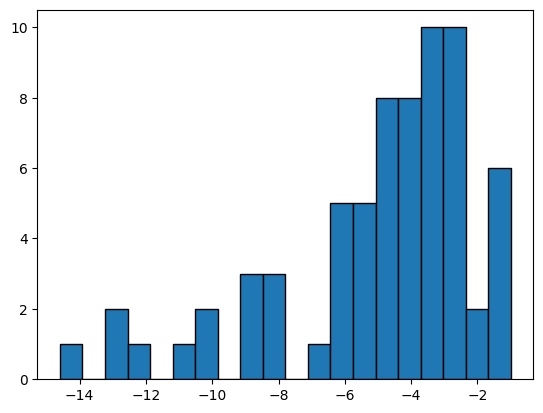

In [8]:
subject_idx = 2
[2,4,6,8,10]
plt.hist(np.log10(Multi_T_test.iloc[subject_idx,10]),edgecolor="black",bins=20)

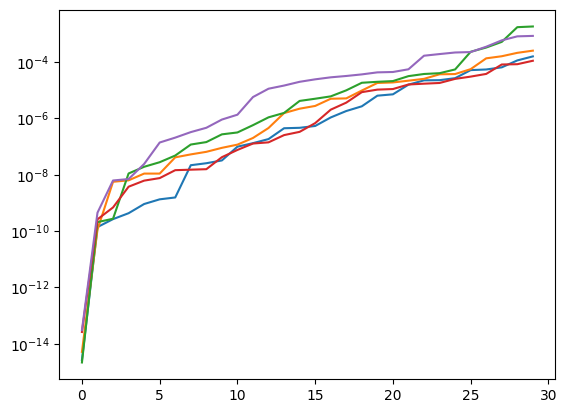

In [ ]:
for fold in [2,]#[_*2+2 for _ in range(5)]:
    plt.plot(Multi_T_test.iloc[5,fold][0:30])
plt.yscale("log")

# Test

[np.int64(2),
 np.int64(32),
 np.int64(33),
 np.int64(46),
 np.int64(25),
 np.int64(59),
 np.int64(3),
 np.int64(47),
 np.int64(15),
 np.int64(50),
 np.int64(22),
 np.int64(42),
 np.int64(58),
 np.int64(62),
 np.int64(24),
 np.int64(45),
 np.int64(51),
 np.int64(21),
 np.int64(19),
 np.int64(53),
 np.int64(6),
 np.int64(9),
 np.int64(49),
 np.int64(5),
 np.int64(20),
 np.int64(0),
 np.int64(14),
 np.int64(34),
 np.int64(1),
 np.int64(7),
 np.int64(28),
 np.int64(38),
 np.int64(43),
 np.int64(41),
 np.int64(30),
 np.int64(52),
 np.int64(63),
 np.int64(44),
 np.int64(23),
 np.int64(56),
 np.int64(12),
 np.int64(54),
 np.int64(27),
 np.int64(18),
 np.int64(17),
 np.int64(10),
 np.int64(40),
 np.int64(35),
 np.int64(66),
 np.int64(29),
 np.int64(16),
 np.int64(4),
 np.int64(36),
 np.int64(11),
 np.int64(61),
 np.int64(39),
 np.int64(65),
 np.int64(55),
 np.int64(67),
 np.int64(57),
 np.int64(60),
 np.int64(13),
 np.int64(31),
 np.int64(48),
 np.int64(37),
 np.int64(64),
 np.int64(26),
 np.

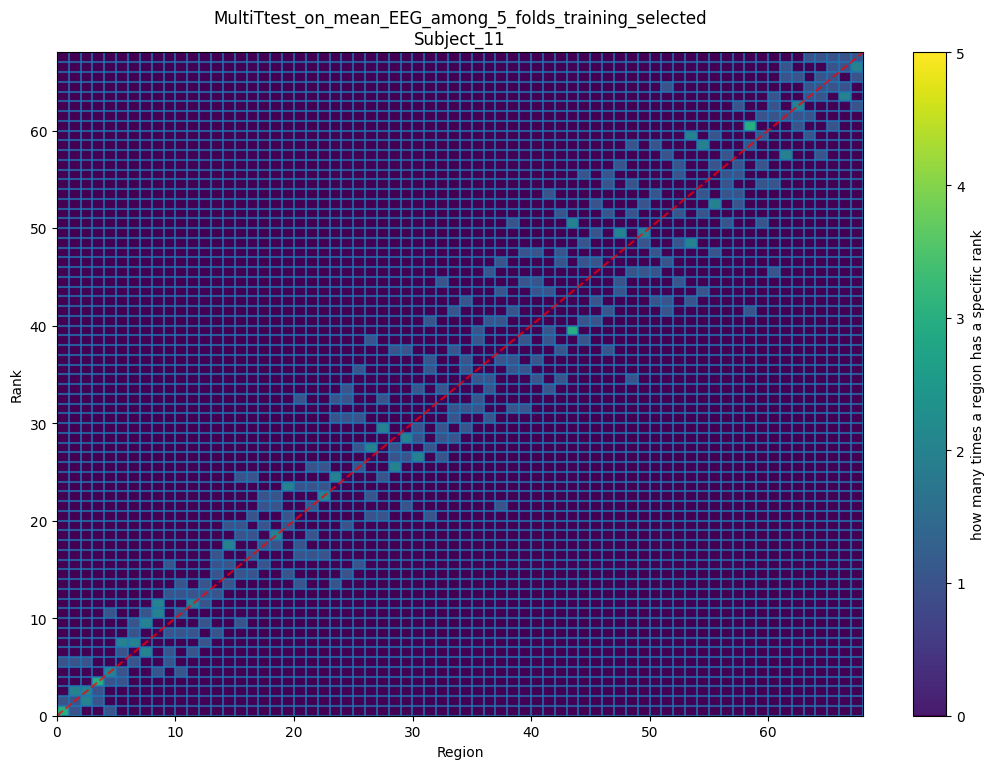

In [125]:
sb = 11

plot_hist2d_selected_regions_folds("/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/" \
"Selected_regions_MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected.pkl",
                            subject=sb, num_best_selected=68, plot_sorted=True, 
                            figtitle=f"MultiTtest_on_mean_EEG_among_5_folds_training_selected\nSubject_{sb}",
                            #save_path="/Users/giovanni.messuti/Desktop/BCI_Project/Images/" \
                            #f"Hist2d_region_selection/MyCriteria_EEG_among_5_folds_training_selected_subject_{sb}_freq_8_30.png"
                            )[1]

[np.int64(47),
 np.int64(4),
 np.int64(45),
 np.int64(0),
 np.int64(44),
 np.int64(49),
 np.int64(21),
 np.int64(48),
 np.int64(24),
 np.int64(1),
 np.int64(5),
 np.int64(38),
 np.int64(12),
 np.int64(57),
 np.int64(15),
 np.int64(62),
 np.int64(14),
 np.int64(37),
 np.int64(28),
 np.int64(30),
 np.int64(60),
 np.int64(18),
 np.int64(25),
 np.int64(3),
 np.int64(32),
 np.int64(61),
 np.int64(23),
 np.int64(53),
 np.int64(67),
 np.int64(17),
 np.int64(52),
 np.int64(64),
 np.int64(63),
 np.int64(59),
 np.int64(2),
 np.int64(66),
 np.int64(16),
 np.int64(29),
 np.int64(34),
 np.int64(31),
 np.int64(65),
 np.int64(43),
 np.int64(56),
 np.int64(9),
 np.int64(55),
 np.int64(19),
 np.int64(51),
 np.int64(13),
 np.int64(7),
 np.int64(40),
 np.int64(35),
 np.int64(8),
 np.int64(39),
 np.int64(11),
 np.int64(33),
 np.int64(54),
 np.int64(58),
 np.int64(46),
 np.int64(10),
 np.int64(26),
 np.int64(27),
 np.int64(22),
 np.int64(20),
 np.int64(50),
 np.int64(42),
 np.int64(41),
 np.int64(6),
 np.i

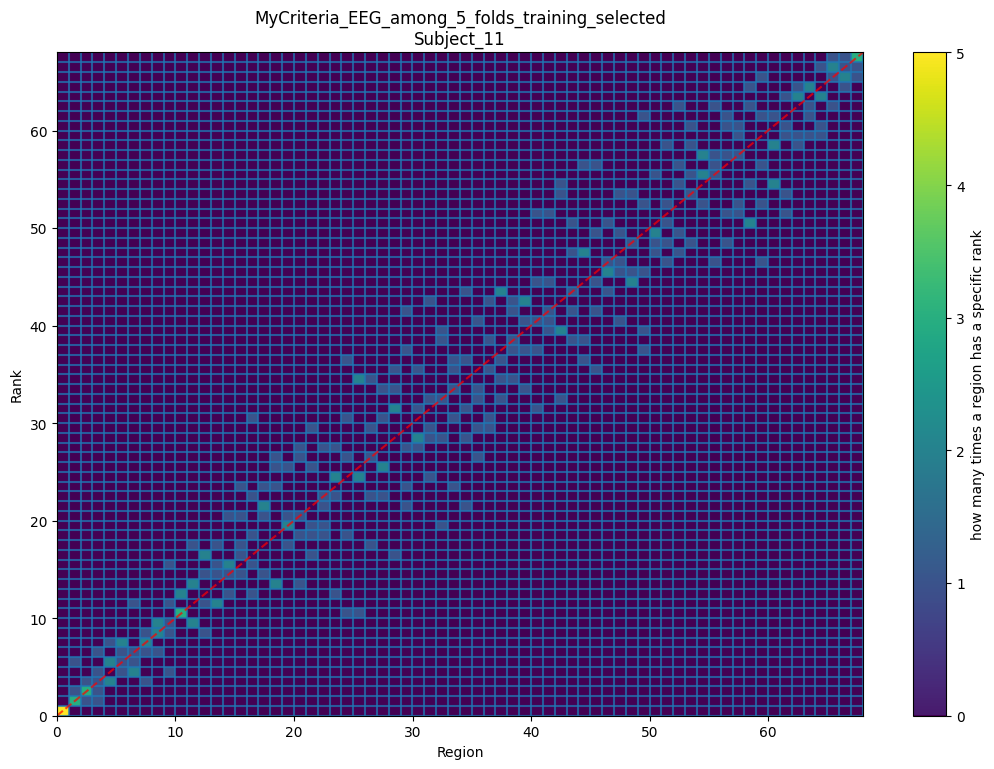

In [121]:
plot_hist2d_selected_regions_folds("/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/" \
"Selected_regions_MyCriteria_EEG_among_5_folds_training_selected_freq_8_30.pkl",
                            subject=sb, num_best_selected=68, plot_sorted=True, 
                            figtitle=f"MyCriteria_EEG_among_5_folds_training_selected\nSubject_{sb}",
                            #save_path="/Users/giovanni.messuti/Desktop/BCI_Project/Images/" \
                            #f"Hist2d_region_selection/MyCriteria_EEG_among_5_folds_training_selected_subject_{sb}_freq_8_30.png"
                            )[1]

In [55]:
patti = "/Users/giovanni.messuti/Desktop/BCI_Project/Results/RegionSelection/" \
"Selected_regions_MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected.pkl"

MultiTmean = pd.read_pickle(patti)
MultiTmean

,Subject,ROIs_fold_1,Pvalues_1,ROIs_fold_2,Pvalues_2,ROIs_fold_3,Pvalues_3,ROIs_fold_4,Pvalues_4,ROIs_fold_5,Pvalues_5
0,0,"(7, 14, 58, 15, 23, 59, 6, 22, 51, 42, 32, 20,...","(2.6e-21, 3.81e-21, 9.2e-20, 5.15e-19, 6.6e-19...","(14, 58, 7, 42, 22, 6, 26, 23, 15, 20, 43, 32,...","(2e-23, 3.33e-21, 6.68e-21, 5.48e-20, 6.14e-20...","(14, 7, 42, 6, 22, 58, 23, 15, 50, 26, 59, 32,...","(1.3e-25, 6.87e-23, 9.58e-22, 1.44e-21, 3.06e-...","(58, 14, 7, 6, 22, 23, 15, 32, 20, 42, 50, 59,...","(3.79e-23, 4.87e-23, 9.96e-20, 1.49e-19, 1.12e...","(14, 7, 15, 58, 6, 23, 22, 42, 59, 20, 32, 50,...","(1.17e-20, 2.05e-20, 1.35e-19, 1.95e-19, 2.31e..."
1,1,"(26, 42, 12, 20, 34, 27, 43, 13, 16, 10, 35, 5...","(1.08e-06, 4.1e-06, 6.63e-06, 8.76e-06, 1.39e-...","(13, 35, 20, 27, 1, 43, 31, 23, 51, 42, 49, 26...","(8.06e-10, 3.72e-08, 1.14e-07, 2.67e-07, 8.24e...","(12, 34, 13, 2, 27, 28, 20, 26, 16, 35, 10, 42...","(7.11e-05, 0.000163, 0.000211, 0.00025, 0.0003...","(20, 13, 26, 42, 2, 27, 35, 43, 34, 12, 51, 0,...","(2.19e-05, 0.000136, 0.000174, 0.000222, 0.000...","(20, 28, 10, 34, 13, 12, 2, 42, 26, 16, 62, 44...","(7.23e-06, 1.6e-05, 1.74e-05, 1.79e-05, 2.79e-..."
2,2,"(32, 33, 51, 49, 5, 4, 27, 43, 14, 59, 17, 42,...","(4.28e-20, 6.71e-16, 7.29e-15, 1.65e-14, 3.23e...","(32, 33, 51, 50, 14, 24, 4, 38, 59, 42, 48, 43...","(1.09e-18, 1.24e-15, 1.12e-13, 1.18e-13, 3.46e...","(32, 51, 24, 4, 14, 33, 38, 11, 10, 48, 27, 50...","(8.34e-18, 1.6e-14, 1.71e-13, 1.86e-13, 6.46e-...","(32, 33, 24, 47, 4, 48, 11, 38, 51, 10, 54, 49...","(4.66e-20, 1.44e-16, 6.8e-14, 8.48e-14, 9.11e-...","(32, 33, 4, 51, 49, 24, 38, 45, 48, 11, 5, 10,...","(2.12e-19, 2.97e-16, 5.23e-14, 1.24e-13, 2.82e..."
3,3,"(23, 15, 22, 7, 4, 14, 51, 44, 43, 48, 42, 50,...","(2.39e-17, 2.63e-13, 2.63e-11, 8.45e-10, 1.15e...","(23, 15, 14, 4, 22, 51, 7, 43, 44, 48, 50, 27,...","(1.34e-17, 1.82e-12, 1.38e-11, 2.97e-11, 9.38e...","(23, 14, 22, 7, 15, 4, 43, 41, 51, 39, 10, 44,...","(4.51e-16, 1.08e-13, 2.65e-13, 1.28e-11, 2.77e...","(23, 22, 15, 7, 14, 4, 43, 51, 44, 42, 48, 6, ...","(4.56e-16, 5.72e-12, 1.59e-11, 1.21e-10, 1.81e...","(23, 22, 15, 14, 7, 43, 4, 44, 51, 6, 48, 42, ...","(2.73e-17, 3.22e-13, 5.59e-13, 2.17e-11, 6.91e..."
4,4,"(16, 30, 12, 32, 43, 42, 47, 26, 18, 27, 60, 5...","(2.55e-07, 3.39e-06, 6.72e-06, 0.000175, 0.000...","(16, 30, 12, 26, 32, 43, 42, 47, 18, 60, 48, 2...","(6.79e-06, 2.78e-05, 6.1e-05, 0.000235, 0.0002...","(16, 12, 30, 43, 26, 32, 42, 27, 47, 46, 20, 1...","(5.04e-06, 6.78e-06, 8.13e-06, 1.4e-05, 1.86e-...","(32, 16, 43, 30, 12, 42, 26, 47, 20, 23, 46, 1...","(1.04e-06, 1.12e-06, 7.44e-06, 7.82e-06, 7.89e...","(16, 30, 32, 12, 47, 52, 53, 26, 29, 56, 57, 4...","(1.39e-06, 9.49e-06, 1.93e-05, 2.86e-05, 4.89e..."
5,5,"(4, 12, 22, 43, 46, 16, 20, 23, 15, 32, 42, 7,...","(1.26e-18, 6.69e-16, 9.78e-16, 2.38e-15, 8.55e...","(4, 22, 46, 43, 15, 42, 23, 16, 20, 12, 26, 27...","(4.23e-21, 1.71e-17, 7.52e-17, 1.21e-16, 5.42e...","(4, 43, 22, 12, 46, 16, 20, 23, 42, 15, 26, 27...","(1.16e-16, 1.19e-16, 1.28e-16, 2.63e-15, 5.02e...","(4, 22, 46, 43, 12, 16, 42, 20, 33, 23, 15, 26...","(1.38e-20, 2.84e-19, 6.95e-19, 1.72e-17, 3.7e-...","(22, 4, 43, 12, 15, 42, 46, 16, 20, 23, 26, 14...","(5.48e-18, 1.65e-17, 2.25e-17, 1.04e-15, 2e-15..."
6,6,"(23, 32, 44, 51, 22, 46, 48, 27, 47, 50, 4, 33...","(1.44e-08, 1.49e-07, 2.09e-06, 4.02e-06, 4.07e...","(32, 22, 23, 51, 48, 44, 46, 4, 47, 50, 58, 6,...","(5.03e-09, 1.11e-07, 1.3e-07, 1.06e-06, 2.09e-...","(23, 32, 44, 51, 22, 48, 27, 46, 50, 43, 20, 5...","(1.2e-08, 1.67e-06, 2.17e-05, 2.28e-05, 3.7e-0...","(23, 32, 46, 51, 27, 44, 22, 48, 43, 4, 47, 50...","(1.86e-09, 2.32e-08, 7.17e-07, 1.95e-06, 1.66e...","(32, 23, 51, 46, 44, 27, 48, 22, 43, 33, 47, 4...","(2.18e-09, 3.85e-09, 5.51e-08, 2.61e-06, 2.87e..."
7,7,"(11, 43, 41, 10, 46, 37, 39, 32, 58, 6, 20, 42...","(1.15e-09, 5.08e-09, 5.69e-08, 3.24e-07, 3.89e...","(41, 11, 10, 43, 39, 22, 56, 44, 42, 6, 32, 37...","(3.75e-09, 7.77e-09, 8.16e-08, 1.83e-06, 5.38e...","